### Natural Language Processing — Complete Interview Preparation

---

**Table of Contents**

**Foundations**
- [Part 1: Foundations and Prerequisites](#part1)
- [Part 2: Text Preprocessing](#part2)
- [Part 3: Text Representation / Feature Extraction](#part3)
- [Part 4: Word Embeddings](#part4)

**Classical NLP**
- [Part 5: Classical NLP Tasks and Techniques](#part5)
- [Part 6: Language Models](#part6)

**Deep Learning for NLP**
- [Part 7: Deep Learning for NLP](#part7)
- [Part 8: Attention Mechanism and Transformers](#part8)

**Modern NLP**
- [Part 9: Pre-trained Language Models](#part9)
- [Part 10: Core NLP Tasks (Applied)](#part10)

**Advanced Topics**
- [Part 11: Information Retrieval and Search](#part11)
- [Part 12: Topic Modeling](#part12)
- [Part 13: Text Clustering and Similarity](#part13)
- [Part 14: Multilingual and Low-Resource NLP](#part14)
- [Part 15: Speech and NLP Interface](#part15)
- [Part 16: Knowledge Graphs and Ontologies](#part16)

**Ethics, Evaluation, and Frontiers**
- [Part 17: Bias, Fairness, and Ethics](#part17)
- [Part 18: Evaluation in NLP](#part18)
- [Part 19: Large Language Models (LLMs)](#part19)
- [Part 20: Industry Applications and Deployment](#part20)
- [Part 21: Research Frontiers](#part21)

**Interview Prep**
- [Master Interview Cheat Sheet](#master-cheatsheet)

In [56]:
# ──────────────────────────────────────────────
# Setup — Install + Import
# ──────────────────────────────────────────────
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for p in ["nltk", "spacy", "scikit-learn", "gensim", "transformers",
           "sentence-transformers", "langchain", "faiss-cpu",
           "matplotlib", "numpy", "pandas", "textblob", "wordcloud"]:
    try:
        install(p)
    except Exception:
        pass

import re, string, collections, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("vader_lexicon", quiet=True)
nltk.download("maxent_ne_chunker", quiet=True)
nltk.download("maxent_ne_chunker_tab", quiet=True)
nltk.download("words", quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, LancasterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

try:
    import spacy
    try:
        nlp_spacy = spacy.load("en_core_web_sm")
    except OSError:
        spacy.cli.download("en_core_web_sm")
        nlp_spacy = spacy.load("en_core_web_sm")
except Exception as e:
    print(f"spaCy not available: {e}")

print("Setup complete")

Setup complete


---

<a id="part1"></a>

### Part 1: Foundations and Prerequisites

---

#### What is Natural Language Processing (NLP)?

NLP is the intersection of computer science, artificial intelligence, and linguistics, focused on enabling computers to understand, interpret, and generate human language. It transforms unstructured text into structured, actionable information.

> **Key distinction**: NLP is the overarching field. NLU (Natural Language Understanding) focuses on comprehension — mapping text to meaning. NLG (Natural Language Generation) focuses on producing human-like text from data or intents.

**History and Evolution**

| Era | Period | Approach | Example |
|-----|--------|----------|---------|
| Rule-based | 1950s-1980s | Hand-crafted grammars and rules | ELIZA chatbot, syntax parsers |
| Statistical | 1990s-2010s | Probabilistic models from data | HMMs, CRFs, n-gram LMs |
| Neural/DL | 2013-2018 | Word embeddings, RNNs, LSTMs | Word2Vec, Seq2Seq, attention |
| Transformer era | 2018-present | Self-attention, pre-training | BERT, GPT, T5, LLMs |

**Core Challenges in NLP**

| Challenge | Example |
|-----------|---------|
| Ambiguity (lexical) | "bank" = river bank or financial bank? |
| Ambiguity (syntactic) | "I saw the man with a telescope" — who has the telescope? |
| Context dependency | "It's cold" — weather or emotional coldness? |
| Sarcasm and irony | "Oh great, another meeting" — positive or negative? |
| Coreference | "Alice told Bob she was leaving" — who is "she"? |
| Idioms and slang | "Break a leg" does not mean injury |
| Multilingual | Same concept expressed differently across 7000+ languages |
| Domain specificity | "Stat" means different things in medicine vs statistics |

<div style="text-align:center">
<img src="https://jalammar.github.io/images/word2vec/king-colored-embedding.png" width="550" />
<br>
<em>Word Embeddings — color-coded vector values for 'king' (GloVe)</em>
</div>


---

#### Mathematics for NLP

**Linear Algebra**: Documents as vectors in high-dimensional space; matrix factorization (LSA/SVD); attention as matrix multiplication QK^T.

**Probability and Statistics**: Language models compute P(word&#124;context); Bayes theorem for classification; conditional probability chains for text generation.

**Information Theory**:

$$H(X) = -\sum_{x} p(x) \log_2 p(x)$$

Entropy measures uncertainty in language. Cross-entropy loss for LMs:

$$H(p, q) = -\sum_{x} p(x) \log q(x)$$

KL divergence measures distribution difference:

$$D_{KL}(P \| Q) = \sum_{x} P(x) \log \frac{P(x)}{Q(x)}$$

**Calculus**: Gradient descent update rule:

$$\theta_{t+1} = \theta_t - \eta \cdot \nabla_{\theta} \mathcal{L}(\theta)$$

Backpropagation through time (BPTT) for RNNs; chain rule enables training deep Transformer stacks.

---

#### Python for NLP

| Tool | Purpose |
|------|---------|
| `str` methods | `.lower()`, `.strip()`, `.split()`, `.replace()` |
| `re` (regex) | Pattern matching: `re.sub(r'[^a-zA-Z\s]', '', text)` |
| File I/O | `open('file.txt').read()` for text corpus loading |

---

#### Key NLP Libraries

| Library | Focus | Best For |
|---------|-------|----------|
| NLTK | Educational, broad coverage | Learning NLP fundamentals, tokenization, stemming |
| spaCy | Industrial-strength, fast | Production NER, POS, dependency parsing |
| HuggingFace Transformers | Pre-trained models | BERT, GPT, T5 fine-tuning and inference |
| Gensim | Topic modeling and embeddings | Word2Vec, LDA, Doc2Vec |
| TextBlob | Simple API | Quick sentiment, noun phrases |
| Stanford CoreNLP/Stanza | Research-grade | Deep parsing, coreference |

<div style="text-align:center">
<img src="https://jalammar.github.io/images/word2vec/king-man-woman-embedding.png" width="550" />
<br>
<em>Comparing embeddings: king, man, woman — notice similarity patterns</em>
</div>


In [57]:
# ──────────────────────────────────────────────
# Part 1: Python String Processing for NLP
# ──────────────────────────────────────────────
text = "Hello World! NLP is Amazing. Let's process TEXT-123 @user #nlp"

# Basic string operations
print("Original :", text)
print("Lowercase:", text.lower())
print("Split    :", text.split())

# Regex: remove special chars, keep only letters and spaces
import re
cleaned = re.sub(r'[^a-zA-Z\s]', '', text)
print("Cleaned  :", cleaned)

# Remove URLs and HTML-like tags
html_text = "<p>Visit https://example.com for NLP resources</p>"
no_html = re.sub(r'<[^>]+>', '', html_text)
no_urls = re.sub(r'https?://\S+', '[URL]', no_html)
print("No HTML/URL:", no_urls)

# Contraction handling (simple approach)
contractions = {"don't": "do not", "can't": "cannot", "it's": "it is",
                "I'm": "I am", "let's": "let us", "won't": "will not"}
sample = "I can't believe it's happening, don't you think?"
for c, expanded in contractions.items():
    sample = sample.replace(c, expanded)
print("Expanded :", sample)

Original : Hello World! NLP is Amazing. Let's process TEXT-123 @user #nlp
Lowercase: hello world! nlp is amazing. let's process text-123 @user #nlp
Split    : ['Hello', 'World!', 'NLP', 'is', 'Amazing.', "Let's", 'process', 'TEXT-123', '@user', '#nlp']
Cleaned  : Hello World NLP is Amazing Lets process TEXT user nlp
No HTML/URL: Visit [URL] for NLP resources
Expanded : I cannot believe it is happening, do not you think?


<div style="text-align:center">
<img src="https://jalammar.github.io/images/word2vec/queen-woman-girl-embeddings.png" width="550" />
<br>
<em>Embeddings for queen, woman, girl, boy, man, water — similar concepts cluster together</em>
</div>


---

<a id="part2"></a>

### Part 2: Text Preprocessing

---

#### Why Preprocessing Matters

Raw text is noisy: mixed case, punctuation, HTML tags, URLs, special characters, abbreviations, contractions. Models need clean, standardized input. Preprocessing transforms raw text into a normalized form suitable for feature extraction and modeling.

> **Rule**: Preprocessing choices depend on the task. Sentiment analysis may keep punctuation (exclamation marks matter). Search engines may remove stop words. Modern Transformers need less preprocessing than classical methods.

**Text Preprocessing Pipeline**

```
Raw Text
  -> Lowercasing
  -> Noise removal (HTML, URLs, special chars)
  -> Contraction expansion
  -> Tokenization (word / sentence / subword)
  -> Stop word removal (optional)
  -> Stemming OR Lemmatization
  -> Final cleaned text
```

---

#### Tokenization

| Type | Input | Output | Use Case |
|------|-------|--------|----------|
| Word | "NLP is great" | ["NLP", "is", "great"] | Classical NLP |
| Sentence | "Hello. How are you?" | ["Hello.", "How are you?"] | Document processing |
| Subword (BPE) | "unhappiness" | ["un", "happiness"] | Transformer models |
| Character | "hello" | ["h","e","l","l","o"] | Morphological analysis |

---

#### Stemming vs Lemmatization

| Feature | Stemming | Lemmatization |
|---------|----------|---------------|
| Method | Rule-based truncation | Dictionary-based reduction |
| Speed | Fast | Slower |
| Output | May not be valid word ("studi") | Always valid word ("study") |
| Context | Ignores POS | Considers POS (noun/verb) |
| Stemmers | Porter, Lancaster, Snowball | WordNet, spaCy |

---

#### Stop Words

Common words ("the", "is", "and") that carry little meaning for many tasks. Removing them reduces vocabulary size and noise.

> **When NOT to remove**: Sentiment analysis ("not good"), question answering ("what"), named entity recognition, Transformer-based models (they handle stopwords inherently).

---

#### Text Normalization

- **Lowercasing**: "NLP" -> "nlp" (loses case info for NER)
- **Noise removal**: HTML tags, URLs, email addresses, special characters
- **Handling abbreviations**: "Dr." -> "Doctor", "U.S." -> "United States"
- **Unicode normalization**: Consistent encoding for multilingual text
- **Social media**: hashtag segmentation (#MachineLearning -> Machine Learning), emoji handling

<div style="text-align:center">
<img src="https://jalammar.github.io/images/word2vec/king-analogy-viz.png" width="550" />
<br>
<em>Word Analogy: king - man + woman ≈ queen — arithmetic in embedding space</em>
</div>


#### Reference: Text Preprocessing Pipeline Overview

<img src="https://nlp.stanford.edu/projects/glove/images/man_woman.jpg" width="550" />

*Source: Standard NLP text preprocessing pipeline — lowercasing, noise removal, tokenization, stop words, stemming/lemmatization*

<div style="font-family:monospace;padding:15px;background:#1a1a2e;color:#e0e0e0;border-radius:8px;font-size:13px">
<b style="color:#4fc3f7">NLP Preprocessing Pipeline</b>
<pre style="color:#e0e0e0">
Raw Text → Tokenization → Lowercasing → Stop Words Removal
    ↓
Stemming / Lemmatization → POS Tagging → Named Entity Recognition
    ↓
Feature Extraction (BoW / TF-IDF / Embeddings) → Model Input
</pre>
</div>


In [58]:
# ──────────────────────────────────────────────
# Part 2: Complete Text Preprocessing Pipeline
# ──────────────────────────────────────────────
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, LancasterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer

raw = "The cats are running quickly! Dr. Smith's NLP research at MIT isn't stopping. Visit https://nlp.stanford.edu"
print("Raw:", raw)

# 1. Sentence tokenization
sentences = sent_tokenize(raw)
print(f"\nSentences ({len(sentences)}):", sentences)

# 2. Word tokenization
tokens = word_tokenize(raw.lower())
print(f"\nTokens ({len(tokens)}):", tokens)

# 3. Remove punctuation and numbers
tokens_clean = [t for t in tokens if t.isalpha()]
print(f"\nAlpha only ({len(tokens_clean)}):", tokens_clean)

# 4. Stop word removal
stop_words = set(stopwords.words('english'))
tokens_no_stop = [t for t in tokens_clean if t not in stop_words]
print(f"\nNo stopwords ({len(tokens_no_stop)}):", tokens_no_stop)

# 5. Stemming comparison
porter = PorterStemmer()
lancaster = LancasterStemmer()
snowball = SnowballStemmer("english")

words = ["running", "cats", "studies", "better", "happily"]
print("\n--- Stemming Comparison ---")
print(f"{'Word':<12} {'Porter':<12} {'Lancaster':<12} {'Snowball':<12}")
for w in words:
    print(f"{w:<12} {porter.stem(w):<12} {lancaster.stem(w):<12} {snowball.stem(w):<12}")

# 6. Lemmatization
lemmatizer = WordNetLemmatizer()
print("\n--- Lemmatization ---")
print(f"{'Word':<12} {'Noun':<12} {'Verb':<12}")
for w in ["running", "cats", "better", "studies", "geese"]:
    print(f"{w:<12} {lemmatizer.lemmatize(w, 'n'):<12} {lemmatizer.lemmatize(w, 'v'):<12}")

Raw: The cats are running quickly! Dr. Smith's NLP research at MIT isn't stopping. Visit https://nlp.stanford.edu

Sentences (3): ['The cats are running quickly!', "Dr. Smith's NLP research at MIT isn't stopping.", 'Visit https://nlp.stanford.edu']

Tokens (21): ['the', 'cats', 'are', 'running', 'quickly', '!', 'dr.', 'smith', "'s", 'nlp', 'research', 'at', 'mit', 'is', "n't", 'stopping', '.', 'visit', 'https', ':', '//nlp.stanford.edu']

Alpha only (14): ['the', 'cats', 'are', 'running', 'quickly', 'smith', 'nlp', 'research', 'at', 'mit', 'is', 'stopping', 'visit', 'https']

No stopwords (10): ['cats', 'running', 'quickly', 'smith', 'nlp', 'research', 'mit', 'stopping', 'visit', 'https']

--- Stemming Comparison ---
Word         Porter       Lancaster    Snowball    
running      run          run          run         
cats         cat          cat          cat         
studies      studi        study        studi       
better       better       bet          better      
happily      

In [59]:
# ──────────────────────────────────────────────
# Part 2: spaCy Preprocessing Pipeline
# ──────────────────────────────────────────────
try:
    doc = nlp_spacy("Apple Inc. is looking at buying a U.K. startup for $1 billion. The company isn't commenting.")

    print("--- spaCy Token Analysis ---")
    print(f"{'Token':<14} {'Lemma':<12} {'POS':<8} {'Stop?':<6} {'Punct?':<6}")
    print("-" * 50)
    for token in doc:
        print(f"{token.text:<14} {token.lemma_:<12} {token.pos_:<8} {str(token.is_stop):<6} {str(token.is_punct):<6}")

    # Named entities
    print("\n--- Named Entities ---")
    for ent in doc.ents:
        print(f"  {ent.text:<20} -> {ent.label_} ({spacy.explain(ent.label_)})")
except Exception as e:
    print(f"spaCy demo skipped: {e}")

--- spaCy Token Analysis ---
Token          Lemma        POS      Stop?  Punct?
--------------------------------------------------
Apple          Apple        PROPN    False  False 
Inc.           Inc.         PROPN    False  False 
is             be           AUX      True   False 
looking        look         VERB     False  False 
at             at           ADP      True   False 
buying         buy          VERB     False  False 
a              a            DET      True   False 
U.K.           U.K.         PROPN    False  False 
startup        startup      NOUN     False  False 
for            for          ADP      True   False 
$              $            SYM      False  False 
1              1            NUM      False  False 
billion        billion      NUM      False  False 
.              .            PUNCT    False  True  
The            the          DET      True   False 
company        company      NOUN     False  False 
is             be           AUX      True   False 
n'

---

#### Parts 1-2 Interview Questions — Foundations and Preprocessing

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is NLP? | NLP, definition | • Field enabling computers to understand, interpret, and generate human language<br>• Intersection of CS, AI, and linguistics<br>• Transforms unstructured text into structured information |
| 2 | NLP vs NLU vs NLG? | NLU, NLG | • NLP: overarching field covering all text/language processing<br>• NLU: comprehension — maps text to meaning (intent, entities)<br>• NLG: production — generates human-like text from data |
| 3 | Key challenges in NLP? | Challenges, ambiguity | • Lexical/syntactic ambiguity ("bank" = multiple meanings)<br>• Context dependency, sarcasm, irony<br>• Coreference resolution, multilingual diversity |
| 4 | NLP evolution eras? | History, evolution | • Rule-based (1950s-80s) -> Statistical (1990s-2010s)<br>• Neural/DL (2013-18): Word2Vec, RNNs, LSTMs<br>• Transformer era (2018+): BERT, GPT, T5 |
| 5 | Why is preprocessing important? | Preprocessing | • Raw text is noisy (HTML, URLs, mixed case, special chars)<br>• Models need clean, standardized input<br>• Preprocessing choices depend on task and model type |
| 6 | Types of tokenization? | Tokenization | • Word: split on whitespace/punctuation ("I am" -> ["I","am"])<br>• Sentence: split text into sentences<br>• Subword (BPE): handles OOV ("unhappy" -> ["un","happy"])<br>• Character: individual chars |
| 7 | Stemming vs lemmatization? | Stemming, lemma | • Stemming: rule-based truncation (fast, may produce non-words)<br>• Lemmatization: dictionary-based (slower, always valid words)<br>• Lemmatization considers POS; stemming doesn't |
| 8 | Three stemmers compared? | Porter, Lancaster, Snowball | • Porter: most common, moderate aggression<br>• Lancaster: most aggressive, sometimes over-stems<br>• Snowball: improved Porter, multilingual support |
| 9 | When to remove stop words? | Stopwords | • Remove: BoW, TF-IDF, topic modeling (noise reduction)<br>• Keep: sentiment analysis ("not"), QA, NER<br>• Transformer models handle stopwords internally |
| 10 | What is text normalization? | Normalization | • Lowercasing, removing special chars, expanding contractions<br>• Unicode normalization for consistent encoding<br>• Social media cleaning: hashtags, emojis, abbreviations |
| 11 | How to handle contractions? | Contractions | • Expand: "don't" -> "do not", "it's" -> "it is"<br>• Use dictionary mapping or regex rules<br>• Important for sentiment and classification tasks |
| 12 | Handling social media text? | Social media, noise | • Remove User mentions (@user), URLs, HTML<br>• Handle hashtag segmentation (#MachineLearning)<br>• Emoji to text conversion; slang normalization |
| 13 | Regex for NLP? | Regex, pattern | • Pattern matching: r'[^a-zA-Z\s]' removes non-alpha<br>• URL removal: r'https?://\S+'<br>• Email detection, tokenization patterns |
| 14 | Key NLP libraries? | NLTK, spaCy, HuggingFace | • NLTK: educational, broad (tokenize, stem, tag)<br>• spaCy: fast, production (NER, parsing, pipelines)<br>• HuggingFace: pre-trained Transformers ecosystem |
| 15 | spaCy vs NLTK? | spaCy, NLTK | • spaCy: faster, production-ready, object-oriented pipeline<br>• NLTK: more tools, better for learning, corpus access<br>• Use spaCy in production; NLTK for education/research |
| 16 | What is lowercasing and when to avoid? | Lowercasing | • Converts all text to lowercase for consistency<br>• Avoid when case carries meaning: NER (Apple vs apple)<br>• Transformers handle mixed case natively |
| 17 | How to handle multilingual text? | Multilingual | • Unicode normalization (NFD/NFC)<br>• Language detection first (langdetect, fasttext-langdetect)<br>• Use multilingual models (mBERT, XLM-R) |
| 18 | What is spelling correction? | Spelling | • Correct typos before processing (TextBlob, pyspellchecker)<br>• Edit distance algorithms (Levenshtein)<br>• Context-aware correction (deep learning based) |
| 19 | POS role in preprocessing? | POS, lemmatization | • Lemmatization needs POS for accuracy ("better" as adj vs verb)<br>• POS filtering: keep only nouns for topic analysis<br>• spaCy assigns POS automatically in pipeline |
| 20 | What is noise in text data? | Noise | • HTML tags, URLs, email addresses, special characters<br>• Repeated characters ("sooooo good"), mixed encoding<br>• Boilerplate text (headers, footers, disclaimers) |
| 21 | Entropy in NLP context? | Entropy, information | • H(X) = -sum(p*log2(p)); measures language uncertainty<br>• Higher entropy = more unpredictable text<br>• Used in LM evaluation and feature selection |
| 22 | Key Python string methods for NLP? | Python, strings | • .lower(), .strip(), .split(), .replace(), .join()<br>• .isalpha(), .isdigit() for filtering<br>• .startswith(), .endswith() for pattern checks |
| 23 | KL divergence in NLP? | KL divergence | • Measures how model distribution differs from true distribution<br>• KL(P&#124;&#124;Q) = sum(P*log(P/Q)); asymmetric<br>• Used in training LMs; related to cross-entropy loss |
| 24 | What is text segmentation? | Segmentation | • Splitting text into meaningful units (words, sentences, paragraphs)<br>• Sentence boundary detection (SBD) handles abbreviations<br>• Chinese/Japanese need word segmentation (no spaces) |
| 25 | Preprocessing for Transformers vs classical? | Transformers, preprocessing | • Classical: heavy preprocessing (stem, remove stopwords, lowercase)<br>• Transformers: minimal (tokenizer handles subwords, case)<br>• Don't over-preprocess for BERT/GPT — they learn from context |

---

<a id="part3"></a>

### Part 3: Text Representation / Feature Extraction

---

#### Why Text Representation Matters

ML models need numerical input. Text representation converts raw text into vectors that capture linguistic features. The quality of representation directly impacts model performance.

---

#### Bag of Words (BoW) and Count Vectorization

BoW represents each document as a vector of word counts, ignoring word order. The vocabulary is the set of all unique words across documents.

> **Limitation**: Loses word order, context, and semantics. "Dog bites man" and "Man bites dog" have identical BoW representations.

---

#### N-grams

Capture local word order by considering sequences of n consecutive words.

| Type | Example ("I love NLP") | Captures |
|------|----------------------|----------|
| Unigram (n=1) | ["I", "love", "NLP"] | Individual words |
| Bigram (n=2) | ["I love", "love NLP"] | Two-word phrases |
| Trigram (n=3) | ["I love NLP"] | Three-word phrases |

> **Tradeoff**: Higher n captures more context but increases vocabulary size exponentially and causes sparsity.

---

#### TF-IDF (Term Frequency-Inverse Document Frequency)

Weights terms by importance: frequent in one document but rare across corpus.

$$\text{TF}(t, d) = \frac{\text{count of } t \text{ in } d}{\text{total words in } d}$$

$$\text{IDF}(t) = \log \frac{N}{\text{df}(t)}$$

where $N$ = total documents, $\text{df}(t)$ = documents containing term $t$

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

> High TF-IDF = important and distinctive word for that document. Common words ("the", "is") get low scores.

---

#### Other Vectorization Methods

| Method | Description | When to Use |
|--------|-------------|-------------|
| Binary vectorization | 1 if word present, 0 if absent | When frequency doesn't matter |
| Hash vectorization | Hash words to fixed-size vector | Very large vocabularies (memory efficient) |
| Co-occurrence matrix | Count word pair co-occurrences in window | Capture word associations (basis for GloVe) |
| PMI (Pointwise Mutual Information) | log(P(x,y) / P(x)*P(y)) | Measure word association strength |
| One-hot encoding | Sparse binary vector per word | Simple baseline; no similarity info |

#### Reference: TF-IDF Vectorization Concept

<table style="margin:auto;border-collapse:collapse;text-align:center;font-size:13px">
<tr style="background:#2a2a4a;color:#4fc3f7"><th style="padding:8px;border:1px solid #444">Term</th><th style="padding:8px;border:1px solid #444">Doc 1</th><th style="padding:8px;border:1px solid #444">Doc 2</th><th style="padding:8px;border:1px solid #444">Doc 3</th><th style="padding:8px;border:1px solid #444">IDF</th><th style="padding:8px;border:1px solid #444">TF-IDF (Doc1)</th></tr>
<tr><td style="padding:8px;border:1px solid #444">"the"</td><td style="padding:8px;border:1px solid #444">3</td><td style="padding:8px;border:1px solid #444">2</td><td style="padding:8px;border:1px solid #444">4</td><td style="padding:8px;border:1px solid #444;color:#ff7043">0.00</td><td style="padding:8px;border:1px solid #444;color:#ff7043">0.00</td></tr>
<tr><td style="padding:8px;border:1px solid #444">"python"</td><td style="padding:8px;border:1px solid #444">5</td><td style="padding:8px;border:1px solid #444">0</td><td style="padding:8px;border:1px solid #444">1</td><td style="padding:8px;border:1px solid #444;color:#66bb6a">0.41</td><td style="padding:8px;border:1px solid #444;color:#66bb6a"><b>2.03</b></td></tr>
<tr><td style="padding:8px;border:1px solid #444">"neural"</td><td style="padding:8px;border:1px solid #444">0</td><td style="padding:8px;border:1px solid #444">4</td><td style="padding:8px;border:1px solid #444">0</td><td style="padding:8px;border:1px solid #444;color:#66bb6a">1.10</td><td style="padding:8px;border:1px solid #444">0.00</td></tr>
</table>
<p style="text-align:center;color:#888;font-size:12px"><em>TF-IDF = TF × IDF — Common words ("the") get low weight, rare domain words ("python", "neural") get high weight</em></p>


In [60]:
# ──────────────────────────────────────────────
# Part 3: Text Representation — BoW, N-grams, TF-IDF
# ──────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer

corpus = [
    "NLP is a subfield of artificial intelligence",
    "Natural language processing uses machine learning",
    "Deep learning has transformed NLP applications",
    "Machine learning and NLP work together"
]

# 1. Bag of Words (Count Vectorization)
count_vec = CountVectorizer()
bow_matrix = count_vec.fit_transform(corpus)
print("=== Bag of Words ===")
print(f"Vocabulary size: {len(count_vec.vocabulary_)}")
print(f"Matrix shape: {bow_matrix.shape}")
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=count_vec.get_feature_names_out())
print(bow_df.to_string())

# 2. Bigrams
bigram_vec = CountVectorizer(ngram_range=(2, 2))
bigram_matrix = bigram_vec.fit_transform(corpus)
print(f"\n=== Bigrams ===")
print(f"Bigram features: {bigram_vec.get_feature_names_out()[:10]}...")

# 3. TF-IDF
tfidf_vec = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(corpus)
print(f"\n=== TF-IDF ===")
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vec.get_feature_names_out())
print(tfidf_df.round(3).to_string())

# 4. Hash Vectorization (fixed-size, memory efficient)
hash_vec = HashingVectorizer(n_features=16, alternate_sign=False)
hash_matrix = hash_vec.fit_transform(corpus)
print(f"\n=== Hash Vectorizer (16 features) ===")
print(f"Shape: {hash_matrix.shape}")
print(f"Non-zero elements: {hash_matrix.nnz}")

=== Bag of Words ===
Vocabulary size: 19
Matrix shape: (4, 19)
   and  applications  artificial  deep  has  intelligence  is  language  learning  machine  natural  nlp  of  processing  subfield  together  transformed  uses  work
0    0             0           1     0    0             1   1         0         0        0        0    1   1           0         1         0            0     0     0
1    0             0           0     0    0             0   0         1         1        1        1    0   0           1         0         0            0     1     0
2    0             1           0     1    1             0   0         0         1        0        0    1   0           0         0         0            1     0     0
3    1             0           0     0    0             0   0         0         1        1        0    1   0           0         0         1            0     0     1

=== Bigrams ===
Bigram features: ['and nlp' 'artificial intelligence' 'deep learning' 'has transformed'
 '

---

<a id="part4"></a>

### Part 4: Word Embeddings

---

#### What are Word Embeddings?

Dense, low-dimensional vectors (50-300d) that capture semantic meaning. Unlike one-hot/BoW, similar words have similar vectors.

> **Key insight**: $\vec{\text{King}} - \vec{\text{Man}} + \vec{\text{Woman}} \approx \vec{\text{Queen}}$ — embeddings capture analogies and relationships.

---

#### Word2Vec (Mikolov et al., 2013)

Two architectures for learning word vectors from context:

| Architecture | How It Works | Strengths |
|-------------|-------------|-----------|
| CBOW (Continuous Bag of Words) | Predict target word from surrounding context | Faster, better for frequent words |
| Skip-gram | Predict context words from target word | Better for rare words, smaller datasets |

**Training techniques**:
- **Negative sampling**: Instead of softmax over entire vocab, sample a few negative examples. Dramatically speeds up training.
- **Hierarchical softmax**: Uses Huffman tree for efficient output probability computation.
- **Window size**: Number of context words (5 is typical). Larger = more topical; smaller = more syntactic.

---

#### GloVe (Global Vectors for Word Representation)

- Factorizes the global word-word co-occurrence matrix
- Combines benefits of count-based (LSA) and predictive (Word2Vec) methods
- Pre-trained on Wikipedia + Gigaword (840B tokens, 300d vectors)

---

#### FastText (Facebook Research)

- Represents words as bags of character n-grams
- "where" = {"wh", "whe", "her", "ere", "re"} + full word
- **Key advantage**: Can generate embeddings for OOV (out-of-vocabulary) words by summing subword vectors
- Better for morphologically rich languages

---

#### Comparison

| Feature | Word2Vec | GloVe | FastText |
|---------|----------|-------|----------|
| Method | Predictive (neural) | Count-based (matrix factorization) | Predictive + subword |
| OOV handling | Cannot handle | Cannot handle | Handles via subwords |
| Training data | Local context window | Global co-occurrence | Local + character n-grams |
| Morphology | Ignores | Ignores | Captures (prefixes, suffixes) |

---

#### Sentence and Document Embeddings

| Method | Approach | Quality |
|--------|----------|---------|
| Average word embeddings | Mean of word vectors | Simple baseline, loses order |
| TF-IDF weighted average | Weight vectors by TF-IDF | Better than plain average |
| Doc2Vec (PV-DM, PV-DBOW) | Learn paragraph-level vectors | Captures document semantics |
| Sentence-BERT | Fine-tuned BERT for sentences | State-of-the-art similarity |

---

#### Visualizing Embeddings

- **PCA**: Linear projection to 2-3D; preserves global structure
- **t-SNE**: Non-linear; preserves local neighborhoods; good for clusters
- **UMAP**: Faster than t-SNE; preserves both local and global structure

#### Reference: Word2Vec — CBOW and Skip-gram

<img src="https://nlp.stanford.edu/projects/glove/images/man_woman.jpg" width="550" />

*Source: CBOW predicts target from context words; Skip-gram predicts context from target word (Mikolov et al., 2013)*

> For a complete visual walkthrough, see [The Illustrated Word2Vec](https://jalammar.github.io/illustrated-word2vec/) by Jay Alammar


=== Word2Vec ===
Vocabulary size: 50
Vector for 'nlp': shape=(50,)
Most similar to 'nlp': [('analysis', 0.311419278383255), ('uses', 0.2970571517944336), ('from', 0.28182247281074524), ('recognition', 0.2682434320449829), ('pre', 0.24082782864570618)]


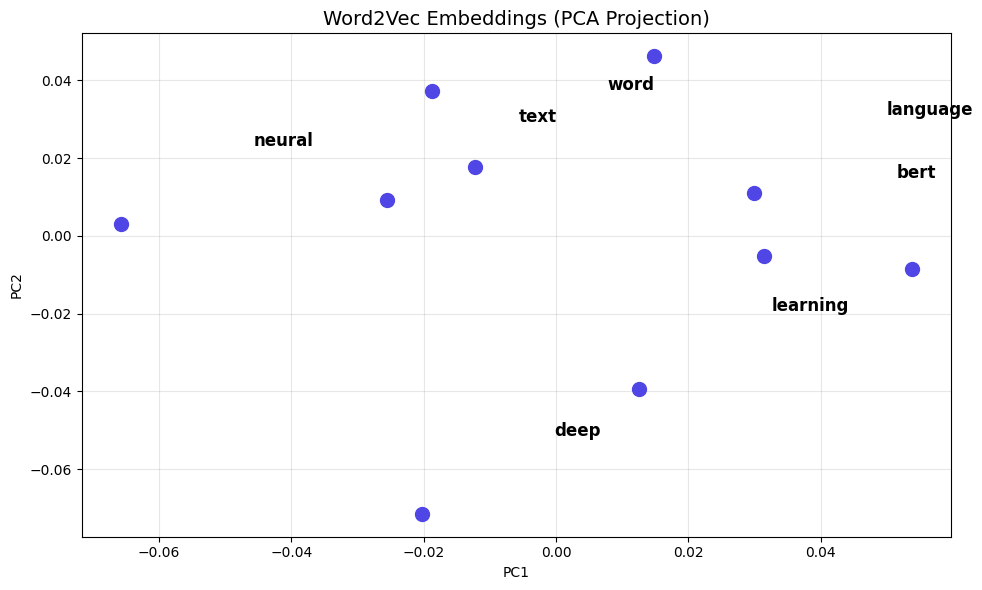

In [61]:
# ──────────────────────────────────────────────
# Part 4: Word Embeddings with Gensim
# ──────────────────────────────────────────────
try:
    from gensim.models import Word2Vec, KeyedVectors
    from sklearn.decomposition import PCA

    # Train Word2Vec on sample sentences
    sentences = [
        ["natural", "language", "processing", "is", "exciting"],
        ["deep", "learning", "transforms", "nlp", "tasks"],
        ["machine", "learning", "uses", "statistical", "methods"],
        ["word", "embeddings", "capture", "semantic", "meaning"],
        ["neural", "networks", "learn", "representations", "from", "data"],
        ["transformers", "use", "attention", "mechanism", "for", "nlp"],
        ["bert", "is", "a", "pre", "trained", "language", "model"],
        ["text", "classification", "sentiment", "analysis", "are", "nlp", "tasks"],
        ["named", "entity", "recognition", "finds", "entities", "in", "text"],
        ["language", "models", "predict", "next", "word", "in", "sequence"],
    ]

    # CBOW model
    model_cbow = Word2Vec(sentences, vector_size=50, window=3, min_count=1, sg=0, epochs=100)

    # Skip-gram model
    model_sg = Word2Vec(sentences, vector_size=50, window=3, min_count=1, sg=1, epochs=100)

    print("=== Word2Vec ===")
    print(f"Vocabulary size: {len(model_sg.wv)}")
    print(f"Vector for 'nlp': shape={model_sg.wv['nlp'].shape}")
    print(f"Most similar to 'nlp': {model_sg.wv.most_similar('nlp', topn=5)}")

    # Visualize embeddings with PCA
    words = ["nlp", "language", "learning", "deep", "neural", "text", "word", "data", "model", "bert"]
    vectors = [model_sg.wv[w] for w in words if w in model_sg.wv]
    labels = [w for w in words if w in model_sg.wv]

    pca = PCA(n_components=2)
    coords = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 6))
    plt.scatter(coords[:, 0], coords[:, 1], c='#4f46e5', s=100, zorder=5)
    for i, label in enumerate(labels):
        plt.annotate(label, (coords[i, 0]+0.02, coords[i, 1]+0.02), fontsize=12, fontweight='bold')
    plt.title("Word2Vec Embeddings (PCA Projection)", fontsize=14)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("Gensim not available — install with: pip install gensim")

---

#### Parts 3-4 Interview Questions — Text Representation and Word Embeddings

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is Bag of Words? | BoW | • Represent doc as word count vector, ignoring order<br>• Vocabulary = union of all unique words<br>• Limitation: "dog bites man" = "man bites dog" |
| 2 | What are n-grams? | N-grams, bigram | • Sequences of n consecutive words<br>• Unigram=1, bigram=2, trigram=3<br>• Higher n captures more context but increases sparsity |
| 3 | Explain TF-IDF? | TF-IDF | • TF: word frequency in doc; IDF: rarity across corpus<br>• TF-IDF = TF * log(N/df); high for distinctive words<br>• Common words ("the") get low scores automatically |
| 4 | TF-IDF vs BoW? | TF-IDF, BoW | • BoW: raw counts (common words dominate)<br>• TF-IDF: weighted (important + rare words highlighted)<br>• TF-IDF usually performs better for classification |
| 5 | What is hash vectorization? | Hash, vectorization | • Map words to fixed-size vector via hash function<br>• Memory efficient (no vocabulary storage)<br>• Cannot invert (no feature names); possible collisions |
| 6 | What is a co-occurrence matrix? | Co-occurrence | • Count how often word pairs appear within a context window<br>• Captures word associations (basis for GloVe)<br>• Large and sparse; factorized by LSA/SVD |
| 7 | What is PMI? | PMI, mutual info | • Pointwise Mutual Information: log(P(x,y)/P(x)*P(y))<br>• Positive = words co-occur more than by chance<br>• Used to find collocations and word associations |
| 8 | What are word embeddings? | Embeddings | • Dense, low-dimensional vectors (50-300d) capturing semantics<br>• Similar words have similar vectors<br>• Learn from context: "king-man+woman=queen" |
| 9 | Word2Vec CBOW vs Skip-gram? | CBOW, Skip-gram | • CBOW: predict target from context (faster, better for frequent words)<br>• Skip-gram: predict context from target (better for rare words)<br>• Skip-gram generally preferred |
| 10 | What is negative sampling? | Negative sampling | • Training efficiency: instead of full softmax over vocab<br>• Sample few negative (non-context) words<br>• Dramatically speeds up Word2Vec training |
| 11 | How does GloVe work? | GloVe | • Factorizes global word co-occurrence matrix<br>• Combines count-based and predictive approaches<br>• Pre-trained on 840B tokens (Wikipedia + Gigaword) |
| 12 | How does FastText handle OOV? | FastText, OOV | • Represents words as bags of character n-grams<br>• OOV word vector = sum of its subword vectors<br>• Better for morphologically rich languages |
| 13 | Word2Vec vs GloVe vs FastText? | Comparison | • Word2Vec: predictive, no OOV handling<br>• GloVe: count-based, global stats, no OOV<br>• FastText: predictive + subwords, handles OOV |
| 14 | What is Doc2Vec? | Doc2Vec | • Extends Word2Vec to document-level<br>• PV-DM: distributed memory (like CBOW with doc vector)<br>• PV-DBOW: predict words from doc vector (like skip-gram) |
| 15 | How to get sentence embeddings? | Sentence embedding | • Average word vectors (baseline)<br>• TF-IDF weighted average (better baseline)<br>• Sentence-BERT: state-of-the-art (fine-tuned Transformer) |
| 16 | PCA vs t-SNE vs UMAP for viz? | PCA, t-SNE, UMAP | • PCA: linear, fast, preserves global structure<br>• t-SNE: non-linear, preserves local neighborhoods, slow<br>• UMAP: fast non-linear, preserves both local+global |
| 17 | Window size in Word2Vec? | Window size | • Number of context words considered (typically 5)<br>• Larger window: more topical/semantic similarity<br>• Smaller window: more syntactic/functional similarity |
| 18 | Static vs contextual embeddings? | Static, contextual | • Static (Word2Vec/GloVe): same vector regardless of context<br>• Contextual (BERT/ELMo): different vector per context<br>• Contextual captures polysemy ("bank" river vs financial) |
| 19 | One-hot encoding limitations? | One-hot | • Very high dimensional (vocab size)<br>• No similarity info (all words equidistant)<br>• Sparse and memory inefficient |
| 20 | What is word analogy? | Analogy | • Vector arithmetic captures relationships<br>• king - man + woman = queen<br>• Paris - France + Italy = Rome |
| 21 | Pre-trained embeddings — how to use? | Pre-trained | • Load pre-trained vectors (e.g., glove.6B.300d.txt)<br>• Use as initial weights in neural models<br>• Fine-tune or freeze depending on data size |
| 22 | What is one-hot vs dense? | One-hot, dense | • One-hot: sparse, high-dim, no semantics (vocab-sized)<br>• Dense: compact (50-300d), captures meaning<br>• Dense learned from data distribution |
| 23 | Hierarchical softmax? | Hierarchical softmax | • Tree structure for efficient output probability<br>• O(log V) instead of O(V) for vocabulary V<br>• Alternative to negative sampling for Word2Vec |
| 24 | Vector space properties? | Vector space | • Cosine similarity measures direction (not magnitude)<br>• L2 distance measures absolute difference<br>• Embeddings form clusters for related words |
| 25 | Embeddings for classification? | Embeddings, classify | • Represent document as average/sum of word embeddings<br>• Feed into classifier (SVM, LogReg, neural)<br>• Feature: dense vector instead of sparse BoW |

<!-- Word Embeddings — One-Hot vs Dense -->
<div style="text-align:center">
<img src="https://jalammar.github.io/images/word2vec/word2vec-embedding-context-matrix.png" width="550" />
<br>
<em></em>
</div>


<div style="text-align:center">
<img src="https://jalammar.github.io/images/word2vec/word2vec-negative-sampling-2.png" width="550" />
<br>
<em>Negative Sampling — contrast real neighbors (positive) with random words (negative)</em>
</div>


<div style="font-family:monospace;padding:15px;background:#1a1a2e;color:#e0e0e0;border-radius:8px;font-size:14px;text-align:center">
<b style="color:#4fc3f7">Named Entity Recognition — BIO Tagging</b><br><br>
<table style="margin:auto;border-collapse:collapse;text-align:center">
<tr style="color:#888"><td style="padding:6px 12px">John</td><td style="padding:6px 12px">Smith</td><td style="padding:6px 12px">works</td><td style="padding:6px 12px">at</td><td style="padding:6px 12px">Google</td><td style="padding:6px 12px">in</td><td style="padding:6px 12px">New</td><td style="padding:6px 12px">York</td></tr>
<tr><td style="padding:6px 12px;color:#42a5f5"><b>B-PER</b></td><td style="padding:6px 12px;color:#42a5f5"><b>I-PER</b></td><td style="padding:6px 12px;color:#888">O</td><td style="padding:6px 12px;color:#888">O</td><td style="padding:6px 12px;color:#66bb6a"><b>B-ORG</b></td><td style="padding:6px 12px;color:#888">O</td><td style="padding:6px 12px;color:#ff7043"><b>B-LOC</b></td><td style="padding:6px 12px;color:#ff7043"><b>I-LOC</b></td></tr>
</table>
</div>


<div style="font-family:monospace;padding:15px;background:#1a1a2e;color:#e0e0e0;border-radius:8px;font-size:14px;text-align:center">
<b style="color:#4fc3f7">Named Entity Recognition — BIO Tagging</b><br><br>
<table style="margin:auto;border-collapse:collapse;text-align:center">
<tr style="color:#888"><td style="padding:6px 12px">John</td><td style="padding:6px 12px">Smith</td><td style="padding:6px 12px">works</td><td style="padding:6px 12px">at</td><td style="padding:6px 12px">Google</td><td style="padding:6px 12px">in</td><td style="padding:6px 12px">New</td><td style="padding:6px 12px">York</td></tr>
<tr><td style="padding:6px 12px;color:#42a5f5"><b>B-PER</b></td><td style="padding:6px 12px;color:#42a5f5"><b>I-PER</b></td><td style="padding:6px 12px;color:#888">O</td><td style="padding:6px 12px;color:#888">O</td><td style="padding:6px 12px;color:#66bb6a"><b>B-ORG</b></td><td style="padding:6px 12px;color:#888">O</td><td style="padding:6px 12px;color:#ff7043"><b>B-LOC</b></td><td style="padding:6px 12px;color:#ff7043"><b>I-LOC</b></td></tr>
</table>
</div>


In [62]:
# ──────────────────────────────────────────────
# Part 5: POS Tagging, NER, and Dependency Parsing
# ──────────────────────────────────────────────
# NLTK POS Tagging
import nltk
text = "Albert Einstein published his theory of relativity at Princeton University in 1915."
tokens = word_tokenize(text)
pos_tags = nltk.pos_tag(tokens)
print("=== NLTK POS Tagging ===")
for word, tag in pos_tags:
    print(f"  {word:<15} -> {tag}")

# NLTK NER
print("\n=== NLTK Named Entity Recognition ===")
chunks = nltk.ne_chunk(pos_tags)
for chunk in chunks:
    if hasattr(chunk, 'label'):
        entity = " ".join(c[0] for c in chunk)
        print(f"  {entity:<25} -> {chunk.label()}")

# spaCy full pipeline
try:
    doc = nlp_spacy(text)
    print("\n=== spaCy POS + NER + Dependencies ===")
    print(f"{'Token':<14} {'POS':<6} {'Tag':<6} {'Dep':<12} {'Head':<14}")
    print("-" * 55)
    for token in doc:
        print(f"{token.text:<14} {token.pos_:<6} {token.tag_:<6} {token.dep_:<12} {token.head.text:<14}")

    print("\n--- Named Entities ---")
    for ent in doc.ents:
        print(f"  {ent.text:<25} -> {ent.label_}")
except Exception as e:
    print(f"spaCy skipped: {e}")

=== NLTK POS Tagging ===
  Albert          -> NNP
  Einstein        -> NNP
  published       -> VBD
  his             -> PRP$
  theory          -> NN
  of              -> IN
  relativity      -> NN
  at              -> IN
  Princeton       -> NNP
  University      -> NNP
  in              -> IN
  1915            -> CD
  .               -> .

=== NLTK Named Entity Recognition ===
  Albert                    -> PERSON
  Einstein                  -> PERSON
  Princeton University      -> ORGANIZATION

=== spaCy POS + NER + Dependencies ===
Token          POS    Tag    Dep          Head          
-------------------------------------------------------
Albert         PROPN  NNP    compound     Einstein      
Einstein       PROPN  NNP    nsubj        published     
published      VERB   VBD    ROOT         published     
his            PRON   PRP$   poss         theory        
theory         NOUN   NN     dobj         published     
of             ADP    IN     prep         theory        
rel

<div style="text-align:center">
<img src="https://jalammar.github.io/images/word2vec/word2vec-training-update.png" width="500" />
<br>
<em>Word2Vec training: compute dot product → sigmoid → error → update embeddings</em>
</div>


In [63]:
# ──────────────────────────────────────────────
# Part 5: Keyword Extraction
# ──────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
    "Machine learning algorithms learn patterns from data to make predictions",
    "Deep learning uses neural networks with multiple layers for complex tasks",
    "Natural language processing enables computers to understand human language",
]

# TF-IDF based keyword extraction
tfidf = TfidfVectorizer(max_features=20, stop_words='english')
matrix = tfidf.fit_transform(documents)
feature_names = tfidf.get_feature_names_out()

print("=== TF-IDF Keywords per Document ===")
for i, doc in enumerate(documents):
    scores = matrix[i].toarray()[0]
    top_idx = scores.argsort()[-5:][::-1]
    keywords = [(feature_names[j], round(scores[j], 3)) for j in top_idx if scores[j] > 0]
    print(f"\nDoc {i+1}: {doc[:50]}...")
    for word, score in keywords:
        print(f"  {word:<20} {score}")

=== TF-IDF Keywords per Document ===

Doc 1: Machine learning algorithms learn patterns from da...
  algorithms           0.363
  make                 0.363
  predictions          0.363
  patterns             0.363
  data                 0.363

Doc 2: Deep learning uses neural networks with multiple l...
  tasks                0.39
  multiple             0.39
  deep                 0.39
  layers               0.39
  neural               0.39

Doc 3: Natural language processing enables computers to u...
  language             0.667
  computers            0.333
  enables              0.333
  natural              0.333
  human                0.333


---

<a id="part6"></a>

### Part 6: Language Models

---

#### What is a Language Model?

A language model assigns probability to sequences of words. It answers: "How likely is this sentence?" or "What word comes next?"

$$P(w_1, w_2, \ldots, w_n) = \prod_{i=1}^{n} P(w_i \mid w_1, \ldots, w_{i-1})$$

Example: $P(\text{"I love NLP"}) = P(\text{I}) \times P(\text{love} \mid \text{I}) \times P(\text{NLP} \mid \text{I, love})$

---

#### N-gram Language Models

Approximate P(word&#124;history) using only the last n-1 words (Markov assumption).

| Model | Formula | Example |
|-------|---------|---------|
| Unigram | P(w) | P based on word frequency |
| Bigram | P(w&#124;w_{n-1}) | P(NLP&#124;love) |
| Trigram | P(w&#124;w_{n-2}, w_{n-1}) | P(NLP&#124;I, love) |

**Perplexity**:

$$\text{PPL}(W) = 2^{H(W)} = 2^{-\frac{1}{N} \sum_{i=1}^{N} \log_2 P(w_i \mid w_{<i})}$$

Lower perplexity = better predictions. $\text{PPL}=1$ means perfect; $\text{PPL}=|V|$ means random.

**Smoothing Techniques** (handle unseen n-grams):

| Technique | Idea |
|-----------|------|
| Laplace (add-1) | Add 1 to all counts; simple but poor for large vocab |
| Add-k smoothing | Add k < 1 instead of 1 |
| Good-Turing | Re-estimate counts using frequency of frequencies |
| Kneser-Ney | Best performing; uses continuation probability |
| Backoff | If trigram unseen, fall back to bigram, then unigram |
| Interpolation | Weighted mix of n-gram, (n-1)-gram, etc. |

---

#### Neural Language Models

| Model | Architecture | Key Idea |
|-------|-------------|----------|
| Feed-forward NNLM (Bengio 2003) | Fixed context window + hidden layers | First neural LM; learned embeddings |
| RNN LM | Recurrent hidden state | Variable context; sequential processing |
| LSTM LM | Long Short-Term Memory | Handles long-range dependencies |
| Transformer LM | Self-attention | Parallel processing; modern standard |

> **Statistical vs Neural LMs**: Statistical (n-gram) = fast, interpretable, limited context. Neural = powerful, captures long-range patterns, needs more compute.

In [64]:
# ──────────────────────────────────────────────
# Part 6: N-gram Language Model from Scratch
# ──────────────────────────────────────────────
import collections, math

corpus = [
    "i love natural language processing",
    "i love machine learning",
    "natural language processing is exciting",
    "machine learning uses data and algorithms",
    "deep learning is a subset of machine learning",
    "i love deep learning for nlp tasks"
]

# Build bigram model
unigram_counts = collections.Counter()
bigram_counts = collections.Counter()

for sentence in corpus:
    words = ["<s>"] + sentence.split() + ["</s>"]
    for w in words:
        unigram_counts[w] += 1
    for w1, w2 in zip(words, words[1:]):
        bigram_counts[(w1, w2)] += 1

vocab_size = len(unigram_counts)
total_words = sum(unigram_counts.values())

print("=== Bigram Language Model ===")
print(f"Vocabulary size: {vocab_size}")
print(f"Total words: {total_words}")

# Top bigrams
print("\nTop 10 bigrams:")
for (w1, w2), count in bigram_counts.most_common(10):
    prob = count / unigram_counts[w1]
    print(f"  P({w2} | {w1}) = {count}/{unigram_counts[w1]} = {prob:.3f}")

# Predict next word
def predict_next(word, top_k=3):
    candidates = {(w1, w2): c for (w1, w2), c in bigram_counts.items() if w1 == word}
    total = sum(candidates.values())
    ranked = sorted(candidates.items(), key=lambda x: -x[1])[:top_k]
    return [(w2, c/total) for (w1, w2), c in ranked]

print("\nPredict next word after 'i':", predict_next("i"))
print("Predict next word after 'machine':", predict_next("machine"))

# Compute perplexity
def sentence_perplexity(sentence):
    words = ["<s>"] + sentence.split() + ["</s>"]
    log_prob = 0
    n = 0
    for w1, w2 in zip(words, words[1:]):
        count = bigram_counts.get((w1, w2), 0)
        # Laplace smoothing
        prob = (count + 1) / (unigram_counts[w1] + vocab_size)
        log_prob += math.log2(prob)
        n += 1
    return 2 ** (-log_prob / n)

test = "i love machine learning"
print(f"\nPerplexity of '{test}': {sentence_perplexity(test):.2f}")
test2 = "algorithms love exciting language"
print(f"Perplexity of '{test2}': {sentence_perplexity(test2):.2f}")
print("(Lower perplexity = more likely sentence)")

=== Bigram Language Model ===
Vocabulary size: 22
Total words: 47

Top 10 bigrams:
  P(i | <s>) = 3/6 = 0.500
  P(love | i) = 3/3 = 1.000
  P(learning | machine) = 3/3 = 1.000
  P(language | natural) = 2/2 = 1.000
  P(processing | language) = 2/2 = 1.000
  P(</s> | learning) = 2/5 = 0.400
  P(learning | deep) = 2/2 = 1.000
  P(natural | love) = 1/3 = 0.333
  P(</s> | processing) = 1/2 = 0.500
  P(machine | love) = 1/3 = 0.333

Predict next word after 'i': [('love', 1.0)]
Predict next word after 'machine': [('learning', 1.0)]

Perplexity of 'i love machine learning': 7.90
Perplexity of 'algorithms love exciting language': 24.53
(Lower perplexity = more likely sentence)


<div style="text-align:center">
<img src="https://jalammar.github.io/images/bert-base-bert-large.png" width="550" />
<br>
<em>BERT Base (12 layers, 110M params) vs BERT Large (24 layers, 340M params)</em>
</div>


---

#### Parts 5-6 Interview Questions — Classical NLP and Language Models

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is POS tagging? | POS | • Assigns grammatical category (noun, verb, adj) to each token<br>• Tags: NN (noun), VB (verb), JJ (adjective), RB (adverb)<br>• Used in: parsing, lemmatization, information extraction |
| 2 | HMM for POS tagging? | HMM, POS | • Hidden states = POS tags; observations = words<br>• Transition probs: P(tag&#124;prev_tag); Emission: P(word&#124;tag)<br>• Viterbi algorithm finds most likely tag sequence |
| 3 | What is NER? | NER | • Identify and classify named entities (person, org, location, date)<br>• BIO tagging: B-PER (begin), I-PER (inside), O (outside)<br>• Modern: fine-tuned BERT with token classification head |
| 4 | BIO vs BIOES tagging? | BIO, BIOES | • BIO: Begin, Inside, Outside (3 tag types per entity)<br>• BIOES: adds Single and End tags (more precise boundaries)<br>• BIOES slightly better for short entities |
| 5 | Dependency vs constituency parsing? | Parsing | • Dependency: word-to-word relationships (subject, object, modifier)<br>• Constituency: hierarchical phrase structure (NP, VP, PP)<br>• Dependency more common in modern NLP (spaCy) |
| 6 | What is coreference resolution? | Coreference | • Link pronouns/references to their antecedents<br>• "Alice told Bob she was leaving" — "she" = Alice<br>• Important for: QA, summarization, dialogue |
| 7 | Word sense disambiguation? | WSD | • Determine correct meaning of polysemous words<br>• "Bank" = financial institution vs river bank<br>• Approaches: Lesk algorithm, knowledge-based, supervised ML |
| 8 | RAKE algorithm? | RAKE, keywords | • Rapid Automatic Keyword Extraction<br>• Uses word co-occurrence and frequency in candidate phrases<br>• No training needed; language-agnostic |
| 9 | What is chunking? | Chunking | • Group words into phrases (NP, VP) without full parse tree<br>• Shallow parsing — less complex than full parsing<br>• Uses POS tags + rules or ML to identify chunks |
| 10 | What is a language model? | LM | • Assigns probability to word sequences<br>• Predicts P(next word&#124;context)<br>• Foundation of: text generation, speech recognition, MT |
| 11 | N-gram language model? | N-gram, LM | • Approximate P(word&#124;history) using last n-1 words<br>• Bigram: P(w&#124;w_{n-1}); Trigram: P(w&#124;w_{n-2},w_{n-1})<br>• Simple but limited context window |
| 12 | What is perplexity? | Perplexity | • PPL = 2^(cross-entropy); measures LM prediction quality<br>• Lower = better; PPL=1 perfect; PPL=&#124;V&#124; random<br>• Standard evaluation metric for language models |
| 13 | Why smoothing in n-gram LMs? | Smoothing | • Handle unseen n-grams (zero probability problem)<br>• Laplace: add 1 to all counts (over-smooths)<br>• Kneser-Ney: best; uses continuation probability |
| 14 | Kneser-Ney smoothing? | Kneser-Ney | • Discounts fixed amount from observed counts<br>• Distributes mass to unseen n-grams based on word versatility<br>• "Francisco" likely after "San" but not generally common |
| 15 | Statistical vs neural LMs? | Statistical, neural | • Statistical: fast, interpretable, limited context (n-gram)<br>• Neural: long-range context, learned representations<br>• Neural dominates since 2018 (Transformers) |
| 16 | Feed-forward NNLM? | NNLM, Bengio | • Bengio 2003: first neural language model<br>• Fixed context window + learned word embeddings<br>• Showed neural LMs can outperform n-gram |
| 17 | Morphological analysis? | Morphology | • Study of word structure: prefix + root + suffix<br>• "unhappiness" = un + happy + ness<br>• Important for: stemming, lemmatization, morphologically rich languages |
| 18 | Language detection? | Detect, language | • Identify which language a text is written in<br>• Methods: character n-gram fingerprinting, fasttext-langdetect<br>• Needed as first step for multilingual pipelines |
| 19 | Lesk algorithm for WSD? | Lesk, WSD | • Compare word's context with dictionary definitions<br>• Choose sense with most overlap between context and gloss<br>• Simple but effective baseline for WSD |
| 20 | CRF for sequence labeling? | CRF | • Conditional Random Field: models entire sequence of labels<br>• Considers label dependencies (I-PER must follow B-PER)<br>• Better than per-token classification for NER/POS |
| 21 | POS tagging approaches evolution? | POS, evolution | • Rule-based -> HMM/CRF -> BiLSTM-CRF -> BERT<br>• Modern: fine-tuned Transformer with token classification<br>• spaCy uses transition-based neural model |
| 22 | Text segmentation? | Segmentation | • Split text into meaningful units (sentences, paragraphs, topics)<br>• Sentence boundary detection handles abbreviations ("Dr.")<br>• Chinese/Japanese: word segmentation (no spaces) |
| 23 | Spell checking approaches? | Spelling | • Edit distance (Levenshtein): min edits to transform word<br>• Noisy channel model: P(correct&#124;observed)<br>• Context-aware: neural models consider surrounding words |
| 24 | Transition vs graph-based parsing? | Parsing, transition | • Transition-based: sequential decisions (shift/reduce), fast O(n)<br>• Graph-based: score all edges, find best tree, accurate O(n^2-3)<br>• spaCy uses transition-based; Stanford uses graph-based |
| 25 | What are Penn Treebank tags? | Penn, tags | • Standard POS tag set (45 tags) for English<br>• NN, NNS, VB, VBD, JJ, RB, DT, IN, etc.<br>• Most widely used English POS tagset |

---

<a id="part7"></a>

### Part 7: Deep Learning for NLP

---

#### Why Deep Learning for NLP?

Classical NLP relies on hand-crafted features. Deep learning automatically learns hierarchical representations from raw text, enabling breakthroughs in translation, generation, understanding, and reasoning.

---

#### Recurrent Neural Networks (RNN)

Process sequences element-by-element, maintaining hidden state that captures information from previous steps.

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

$$y_t = W_y \cdot h_t + b_y$$

**Problem**: Vanishing/exploding gradients when sequences are long. Gradient is multiplied through many time steps — if < 1, vanishes; if > 1, explodes.

**BPTT (Backpropagation Through Time)**: Unroll the RNN and apply standard backprop. Gradient flows through all time steps — source of vanishing gradient problem.

---

#### LSTM (Long Short-Term Memory)

Solves vanishing gradient with gating mechanism and cell state (long-range memory highway).

| Gate | Formula | Purpose |
|------|---------|---------|
| Forget gate | $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$ | What to discard from cell state |
| Input gate | $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$ | What new info to store |
| Candidate | $\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$ | New candidate values |
| Cell state | $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$ | Updated memory |
| Output gate | $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$ | What to output |
| Hidden state | $h_t = o_t \odot \tanh(C_t)$ | Current output |

---

#### GRU (Gated Recurrent Unit)

Simplified LSTM with 2 gates instead of 3 (no separate cell state).

| Gate | Purpose |
|------|---------|
| Reset gate | Controls how much past info to forget |
| Update gate | Controls how much of new state is old vs new |

**RNN vs LSTM vs GRU**: RNN = simple but vanishing gradient. LSTM = 3 gates + cell state, most powerful. GRU = 2 gates, faster, competitive with LSTM.

---

#### Bidirectional and Stacked RNNs

- **Bidirectional**: Process forward AND backward; concatenate hidden states. Full context for each position. Used for NER, POS, classification (not generation).
- **Stacked/Deep RNNs**: Multiple RNN layers stacked. Lower layers capture syntactic, higher layers capture semantic patterns.

---

#### CNN for Text Classification

1D convolutions over word embedding sequences. Filters capture n-gram-like local patterns.

Input: sequence of word embeddings ($n \times d$). Convolution output for filter $w$ of size $h$:

$$c_i = f(w \cdot x_{i:i+h-1} + b)$$

$$\hat{c} = \max(c_1, c_2, \ldots, c_{n-h+1}) \quad \text{(max-over-time pooling)}$$

Multiple filter sizes (3,4,5) capture different n-gram patterns. Concatenate pooled features and classify.

> **Advantage over RNN**: Parallelizable, captures local patterns efficiently. **Limitation**: No long-range dependencies without deep stacking.

---

#### Encoder-Decoder / Seq2Seq Architecture

- **Encoder**: Processes input sequence, produces context vector (final hidden state)
- **Decoder**: Generates output sequence token by token from context vector
- **Teacher forcing**: During training, feed ground truth (not predictions) as decoder input

> **Bottleneck**: Entire input compressed into single fixed-size context vector. Long sequences lose information. Solution: Attention mechanism (Part 8).

#### Reference: Seq2Seq Encoder-Decoder with Attention

<img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-SimpleRNN.png" width="550" />

*Source: Encoder produces context representations; Attention allows decoder to peek at all encoder hidden states, solving the bottleneck problem*

> For animation of the mechanics, see [Visualizing Seq2Seq with Attention](https://jalammar.github.io/visualizing-neural-machine-translation-mechanics-of-seq2seq-models-with-attention/) by Jay Alammar

#### Reference: LSTM Cell Architecture — Gates and Cell State

![LSTM Cell](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-chain.png)

*Source: [Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) by Christopher Olah — the cell state runs as a highway (top line), gates control information flow*

![LSTM Gates Detail](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-focus-f.png)

*The forget gate decides what information to discard from the cell state*

![LSTM vs GRU](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-var-GRU.png)

*GRU variant: combines forget and input gates into a single update gate, simpler than LSTM*

<!-- LSTM Cell Architecture -->
<div style="text-align:center">
<img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-chain.png" width="650" />
<br>
<em>LSTM Chain — Forget gate, input gate, output gate with cell state (Source: colah.github.io)</em>
</div>


In [65]:
# ──────────────────────────────────────────────
# Part 7: LSTM Text Classifier in PyTorch
# ──────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn

    class LSTMClassifier(nn.Module):
        def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
            self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
            self.fc = nn.Linear(hidden_dim * 2, output_dim)  # *2 for bidirectional
            self.dropout = nn.Dropout(0.3)

        def forward(self, x):
            embedded = self.dropout(self.embedding(x))  # (batch, seq_len, embed_dim)
            output, (hidden, cell) = self.lstm(embedded)
            # Concatenate forward and backward hidden states
            hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
            return self.fc(self.dropout(hidden_cat))

    # Demo instantiation
    model = LSTMClassifier(vocab_size=10000, embed_dim=128, hidden_dim=256,
                           output_dim=2, pad_idx=0)
    print("=== BiLSTM Text Classifier ===")
    print(model)

    # Dummy forward pass
    dummy_input = torch.randint(0, 10000, (4, 50))  # batch=4, seq_len=50
    output = model(dummy_input)
    print(f"\nInput shape: {dummy_input.shape}")
    print(f"Output shape: {output.shape}")
    print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

except ImportError:
    print("PyTorch not available — install with: pip install torch")

=== BiLSTM Text Classifier ===
LSTMClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=512, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Input shape: torch.Size([4, 50])
Output shape: torch.Size([4, 2])
Total params: 2,071,554


---

<a id="part8"></a>

### Part 8: Attention Mechanism and Transformers

---

#### Motivation for Attention

Seq2Seq bottleneck: compressing entire input into single vector loses information, especially for long sequences. Attention allows the decoder to "look back" at all encoder positions.

---

#### Attention Types

| Type | Formula | Key Idea |
|------|---------|----------|
| Bahdanau (Additive) | score = V * tanh(W1*h_s + W2*h_t) | Learned alignment; first attention mechanism |
| Luong (Multiplicative) | score = h_t^T * W * h_s | Simpler; dot product with learned weight |
| Scaled Dot-Product | score = (Q * K^T) / sqrt(d_k) | Transformer attention; prevents large values |

---

#### Self-Attention Mechanism

Each position attends to all positions in the same sequence. No recurrence needed.

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

where $Q = XW_Q$, $K = XW_K$, $V = XW_V$ are the query, key, and value projections.

> **Why divide by sqrt(d_k)?** Large d_k makes dot products large, pushing softmax to extreme values (saturated gradients). Scaling keeps variance stable.

---

#### Multi-Head Attention

Run multiple attention operations in parallel (8-32 heads typical). Each head learns different patterns (syntactic, semantic, positional relationships).

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O$$

$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

---

#### Positional Encoding

Self-attention is permutation-invariant — no inherent notion of position. Positional encoding injects order information.

| Type | Method | Used In |
|------|--------|---------|
| Sinusoidal | $PE_{(pos,2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right)$, $PE_{(pos,2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$ | Original Transformer |
| Learned | Trainable embedding per position | BERT, GPT-2 |
| Rotary (RoPE) | Rotation matrices encoding relative position | LLaMA, Mistral |
| ALiBi | Attention bias based on distance | BLOOM, MPT |

---

#### The Transformer Architecture ("Attention is All You Need", 2017)

**Encoder Stack** (x6 layers):
- Multi-head self-attention -> Add and Norm
- Feed-forward network (2 linear layers + ReLU) -> Add and Norm

**Decoder Stack** (x6 layers):
- Masked multi-head self-attention (causal: can't see future) -> Add and Norm
- Multi-head cross-attention (query from decoder, K/V from encoder) -> Add and Norm
- Feed-forward network -> Add and Norm

**Key properties**:
- Parallel processing (not sequential like RNN)
- O(n^2) attention complexity per layer
- Residual connections enable deep stacking
- Layer normalization stabilizes training

---

#### Transformer vs RNN/LSTM

| Feature | RNN/LSTM | Transformer |
|---------|----------|-------------|
| Processing | Sequential | Parallel |
| Long-range deps | Difficult (vanishing gradient) | Direct (self-attention) |
| Training speed | Slow (sequential) | Fast (parallel) |
| Memory | O(1) per position | O(n^2) attention matrix |
| Dominant era | 2015-2018 | 2018-present |

<div style="text-align:center">
<img src="https://jalammar.github.io/images/t/transformer_self_attention_vectors.png" width="550" />
<br>
<em>Self-Attention: each word creates Query, Key, Value vectors from its embedding</em>
</div>


<!-- Transformer Architecture -->
<div style="text-align:center">
<img src="https://machinelearningmastery.com/wp-content/uploads/2021/08/attention_research_1.png" width="350" />
<br>
<em>Transformer Architecture — Encoder (left) + Decoder (right) — Vaswani et al., 2017</em>
</div>


In [66]:
# ──────────────────────────────────────────────
# Part 8: Self-Attention from Scratch
# ──────────────────────────────────────────────
import numpy as np

def self_attention(X, d_k):
    """Scaled dot-product self-attention."""
    # X shape: (seq_len, d_model)
    # Simple: use X itself as Q, K, V (no learned projections)
    Q = K = V = X
    # Attention scores
    scores = Q @ K.T / np.sqrt(d_k)  # (seq_len, seq_len)
    # Softmax
    exp_scores = np.exp(scores - np.max(scores, axis=-1, keepdims=True))
    attention_weights = exp_scores / exp_scores.sum(axis=-1, keepdims=True)
    # Weighted sum of values
    output = attention_weights @ V
    return output, attention_weights

# Demo
np.random.seed(42)
seq_len, d_model = 4, 8
X = np.random.randn(seq_len, d_model)

output, weights = self_attention(X, d_model)

words = ["I", "love", "NLP", "tasks"]
print("=== Self-Attention Weights ===")
print(f"{'':>8}", end="")
for w in words:
    print(f"{w:>8}", end="")
print()
for i, w in enumerate(words):
    print(f"{w:>8}", end="")
    for j in range(len(words)):
        print(f"{weights[i,j]:>8.3f}", end="")
    print()

print(f"\nInput shape:  {X.shape}")
print(f"Output shape: {output.shape}")
print("\nKey insight: Each word attends to all other words.")
print("Highest attention weight in each row = most attended word.")

=== Self-Attention Weights ===
               I    love     NLP   tasks
       I   0.855   0.023   0.019   0.103
    love   0.011   0.776   0.144   0.068
     NLP   0.009   0.142   0.829   0.020
   tasks   0.095   0.129   0.038   0.738

Input shape:  (4, 8)
Output shape: (4, 8)

Key insight: Each word attends to all other words.
Highest attention weight in each row = most attended word.


<!-- Self-Attention Mechanism -->
<div style="text-align:center">
<img src="https://jalammar.github.io/images/t/transformer_self-attention_visualization.png" width="550" />
<br>
<em>Self-Attention — each token attends to all other tokens with learned weights</em>
</div>


---

#### Parts 7-8 Interview Questions — Deep Learning for NLP and Transformers

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | Why deep learning for NLP? | DL, NLP | • Automatically learns hierarchical text representations<br>• No hand-crafted features needed<br>• Breakthroughs in translation, generation, understanding |
| 2 | RNN vanishing gradient? | RNN, vanishing | • Gradient multiplied through many time steps via chain rule<br>• If gradient < 1 at each step: vanishes exponentially<br>• Long-range dependencies not learned; LSTM/GRU solve this |
| 3 | LSTM gates explained? | LSTM, gates | • Forget: what to discard from cell state<br>• Input: what new info to store<br>• Output: what to output from cell state<br>• Cell state: long-range memory highway (additive, not multiplicative) |
| 4 | GRU vs LSTM? | GRU, LSTM | • GRU: 2 gates (reset, update) vs LSTM 3 gates + cell state<br>• GRU: fewer params, faster training<br>• LSTM: slightly more powerful on very long sequences |
| 5 | Bidirectional RNN purpose? | BiRNN | • Process forward AND backward; concatenate hidden states<br>• Each position gets full left + right context<br>• Used for: NER, POS, classification (not autoregressive gen) |
| 6 | CNN for text classification? | CNN, text | • 1D convolutions over word embeddings capture local n-gram patterns<br>• Multiple filter sizes (3,4,5) then max pooling<br>• Fast, parallelizable; good for classification |
| 7 | Seq2Seq bottleneck? | Seq2Seq, bottleneck | • Entire input compressed into single fixed-size context vector<br>• Long sequences lose information<br>• Solution: attention mechanism lets decoder look at all positions |
| 8 | Teacher forcing? | Teacher forcing | • Feed ground truth tokens (not predictions) as decoder input during training<br>• Faster convergence but creates exposure bias<br>• At inference: must use own predictions (train-test mismatch) |
| 9 | What is attention? | Attention | • Mechanism for decoder to look at all encoder positions<br>• Learns soft alignment between input and output<br>• Eliminates Seq2Seq information bottleneck |
| 10 | Bahdanau vs Luong attention? | Bahdanau, Luong | • Bahdanau (additive): score = V*tanh(W1*h_s + W2*h_t)<br>• Luong (multiplicative): score = h_t^T * W * h_s<br>• Luong simpler and often faster |
| 11 | Self-attention explained? | Self-attention | • Each position attends to ALL positions in same sequence<br>• Attention(Q,K,V) = softmax(QK^T/sqrt(d_k))V<br>• Captures long-range dependencies without recurrence |
| 12 | Why divide by sqrt(d_k)? | Scaling, sqrt | • Large d_k makes dot products large -> softmax saturates<br>• Saturated softmax -> vanishing gradients<br>• Scaling keeps variance stable for reliable learning |
| 13 | Multi-head attention? | Multi-head | • Run h parallel attention operations (8-32 heads)<br>• Each head learns different relationship patterns<br>• Concat + linear projection: rich representation |
| 14 | Positional encoding — why needed? | Positional | • Self-attention is permutation-invariant (no position info)<br>• Sinusoidal: fixed sin/cos (original Transformer)<br>• Learned: trainable (BERT); RoPE: rotary (LLaMA) |
| 15 | Transformer encoder vs decoder? | Encoder, decoder | • Encoder: bidirectional self-attention (sees all tokens)<br>• Decoder: causal masked attention (only past tokens)<br>• Cross-attention: decoder queries encoder outputs |
| 16 | Why Transformer beat RNN? | Transformer, RNN | • Parallel processing (not sequential)<br>• Direct long-range attention (no vanishing gradient chain)<br>• Much faster training; scales better with compute |
| 17 | O(n^2) attention problem? | Quadratic, attention | • Each token attends to all n tokens: n^2 scores<br>• Limits sequence length (memory and compute)<br>• Solutions: Flash Attention, sparse attention, linear attention |
| 18 | Residual connections? | Residual, skip | • y = F(x) + x; output = sublayer(input) + input<br>• Gradient flows through identity shortcut<br>• Enables training deep (6+ layer) Transformer stacks |
| 19 | Feed-forward in Transformer? | FFN | • Two linear layers with ReLU: FFN(x) = max(0, xW1+b1)W2+b2<br>• Applied position-wise (same for each token)<br>• Adds non-linearity and capacity between attention layers |
| 20 | Layer normalization in Transformer? | LayerNorm | • Normalize across feature dimension (not batch)<br>• Pre-LN (before sublayer): more stable, no warmup needed<br>• Post-LN (original): harder to train but used in original paper |
| 21 | Masked/causal attention? | Causal, masked | • Upper-triangular mask prevents future token access<br>• Essential for autoregressive generation (GPT)<br>• Each position sees only itself and earlier positions |
| 22 | Cross-attention? | Cross-attention | • Query from decoder; Key/Value from encoder output<br>• How decoder reads and attends to input sequence<br>• Used in encoder-decoder models (T5, translation) |
| 23 | Attention Is All You Need key contributions? | Paper, 2017 | • Eliminated recurrence entirely with self-attention<br>• Multi-head attention for rich representations<br>• Became foundation for BERT, GPT, and all modern NLP |
| 24 | Stacked RNN vs Transformer depth? | Depth | • Stacked RNN: 2-4 layers practical (gradient issues)<br>• Transformer: 6-96 layers (residual connections enable depth)<br>• Each Transformer layer adds attention + FFN capacity |
| 25 | BPTT explained? | BPTT | • Backpropagation Through Time: unroll RNN, apply standard backprop<br>• Gradient flows through all time steps<br>• Source of vanishing/exploding gradient; truncated BPTT limits steps |

---

<a id="part9"></a>

### Part 9: Pre-trained Language Models (PLMs)

---

#### Pre-training and Fine-tuning Paradigm

**Pre-train** on massive unlabeled text (self-supervised) -> learn general language understanding -> **Fine-tune** on small labeled dataset for specific task. Transfer learning: reuse knowledge across tasks.

---

#### ELMo (2018) — Contextual Word Representations

- Bi-directional LSTM producing context-dependent embeddings
- Same word gets different vectors in different contexts ("bank" near "river" vs "money")
- Replaced static embeddings (Word2Vec/GloVe) as state-of-the-art

---

#### GPT (Generative Pre-trained Transformer)

| Version | Params | Key Innovation |
|---------|--------|----------------|
| GPT-1 (2018) | 117M | Transformer decoder + unsupervised pre-training + fine-tuning |
| GPT-2 (2019) | 1.5B | Zero-shot transfer; "too dangerous to release" |
| GPT-3 (2020) | 175B | In-context learning; few-shot via prompting |
| GPT-4 (2023) | Undisclosed (MoE) | Multimodal (text + vision); strongest reasoning |

**Architecture**: Decoder-only Transformer. Unidirectional (causal) language modeling: predict next token. Pre-trained on web text.

---

#### BERT (Bidirectional Encoder Representations from Transformers, 2018)

**Key innovations**:
- **Masked Language Modeling (MLM)**: Randomly mask 15% of tokens, predict them. Enables bidirectional context (unlike GPT's left-to-right).
- **Next Sentence Prediction (NSP)**: Predict if sentence B follows A. (Later found less useful by RoBERTa.)

**Input representation**: [CLS] + tokens_A + [SEP] + tokens_B + [SEP]. WordPiece tokenization. Segment embeddings + positional embeddings.

**Fine-tuning**: Add task-specific head on top of [CLS] token (classification) or token outputs (NER, QA).

---

#### BERT Variants

| Model | Key Change | Benefit |
|-------|-----------|---------|
| RoBERTa | More data, no NSP, dynamic masking, longer training | Better than BERT on all benchmarks |
| DistilBERT | Knowledge distillation (6 layers vs 12) | 60% size, 97% performance, 2x faster |
| ALBERT | Factorized embeddings + cross-layer sharing | Much fewer parameters |
| DeBERTa | Disentangled attention + enhanced mask decoder | State-of-the-art on SuperGLUE |
| XLNet | Permutation-based training | Captures bidirectional context without masking |
| ELECTRA | Replaced Token Detection (generator + discriminator) | More sample-efficient training |

---

#### T5 (Text-to-Text Transfer Transformer)

Reformulates every NLP task as text-to-text:
- Classification: "classify: This movie is great" -> "positive"
- Translation: "translate English to French: Hello" -> "Bonjour"
- Summarization: "summarize: [long text]" -> "[summary]"

Encoder-decoder architecture. Unified framework for all tasks.

---

#### BART (Bidirectional and Auto-Regressive Transformers)

- Encoder-decoder with denoising pre-training
- Corrupts text (masking, deletion, permutation) then reconstructs
- Strong for: summarization, generation, translation

---

#### Sentence-BERT (SBERT)

- Fine-tuned BERT for sentence embeddings via siamese/triplet networks
- Produces semantically meaningful sentence vectors
- Enables efficient similarity search with cosine similarity

---

#### HuggingFace Ecosystem

| Component | Purpose |
|-----------|---------|
| Transformers library | Unified API for 500K+ models (AutoModel, pipeline) |
| Tokenizers library | Fast BPE/WordPiece tokenization in Rust |
| Datasets library | Efficient data loading with Apache Arrow |
| Model Hub | Share and discover pre-trained models |
| Trainer API | Complete training loop with logging, evaluation |

---

#### Prompting and In-Context Learning

| Method | Description |
|--------|-------------|
| Zero-shot | No examples; just task instruction |
| One-shot | One example in prompt |
| Few-shot | 2-5 examples in prompt |
| Chain-of-thought | "Let's think step by step" reasoning |

<div style="text-align:center">
<img src="https://jalammar.github.io/images/t/The_transformer_encoder_decoder_stack.png" width="500" />
<br>
<em>Transformer: stack of N encoder blocks (left) and N decoder blocks (right)</em>
</div>


#### Reference: BERT vs GPT Architecture

<div style="text-align:center">
<img src="https://jalammar.github.io/images/bert-transfer-learning.png" width="550" />
</div>
*Source: BERT input = Token Embeddings + Segment Embeddings + Position Embeddings. [CLS] for classification, [SEP] separates sentence pairs*

<div style="text-align:center">
<img src="https://jalammar.github.io/images/t/Transformer_encoder.png" width="400" />
<br>
<em>Encoder block: Self-Attention → Add & Norm → Feed Forward → Add & Norm</em>
</div>


<div style="text-align:center">
<img src="https://jalammar.github.io/images/bert-input-output.png" width="550" />
<br>
<em>BERT input: [CLS] + tokens + [SEP] → contextualized output embeddings</em>
</div>


<div style="text-align:center">
<img src="https://jalammar.github.io/images/t/transformer_decoding_2.gif" width="550" />
<br>
<em>Transformer Decoding: autoregressive generation one token at a time</em>
</div>


<div style="font-family:monospace;padding:15px;background:#1a1a2e;color:#e0e0e0;border-radius:8px;font-size:13px;text-align:center">
<b style="color:#4fc3f7;font-size:15px">BERT vs GPT Architecture</b><br><br>
<table style="margin:auto;border-collapse:collapse;text-align:center">
<tr><td style="padding:10px 25px;border:2px solid #42a5f5;border-radius:6px;vertical-align:top"><b style="color:#42a5f5">BERT (Encoder)</b><br><br>Bidirectional<br>Self-Attention<br>↕ sees all tokens ↕<br><br>MLM + NSP<br><br><span style="color:#888">Classification<br>NER, QA</span></td>
<td style="padding:10px 25px;border:2px solid #66bb6a;border-radius:6px;vertical-align:top"><b style="color:#66bb6a">GPT (Decoder)</b><br><br>Causal (Left→Right)<br>Self-Attention<br>→ sees past only →<br><br>Next Token Prediction<br><br><span style="color:#888">Text Generation<br>Chat, Code</span></td>
<td style="padding:10px 25px;border:2px solid #ff7043;border-radius:6px;vertical-align:top"><b style="color:#ff7043">T5 (Enc-Dec)</b><br><br>Encoder: Bidirectional<br>Decoder: Cross + Causal<br>↔ source → target →<br><br>Span Corruption<br><br><span style="color:#888">Translation<br>Summarization</span></td></tr>
</table>
</div>


<div style="text-align:center">
<img src="https://jalammar.github.io/images/t/Transformer_decoder.png" width="400" />
<br>
<em>Decoder block: Masked Self-Attention → Encoder-Decoder Attention → Feed Forward</em>
</div>


In [67]:
# ──────────────────────────────────────────────
# Part 9: HuggingFace Transformers Pipeline
# ──────────────────────────────────────────────
try:
    from transformers import pipeline

    # Sentiment Analysis
    print("=== Sentiment Analysis ===")
    classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
    texts = ["I love this product!", "This is terrible.", "It was okay, nothing special."]
    for text in texts:
        result = classifier(text)[0]
        print(f"  '{text}' -> {result['label']} ({result['score']:.3f})")

    # Zero-shot Classification
    print("\n=== Zero-Shot Classification ===")
    zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
    result = zero_shot("The stock market crashed today due to inflation fears",
                       candidate_labels=["finance", "sports", "technology", "health"])
    for label, score in zip(result["labels"][:3], result["scores"][:3]):
        print(f"  {label}: {score:.3f}")

except Exception as e:
    print(f"HuggingFace pipeline demo skipped: {e}")
    print("Install: pip install transformers torch")

=== Sentiment Analysis ===


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1067.89it/s, Materializing param=pre_classifier.weight]                                  


  'I love this product!' -> POSITIVE (1.000)
  'This is terrible.' -> NEGATIVE (1.000)
  'It was okay, nothing special.' -> NEGATIVE (0.982)

=== Zero-Shot Classification ===


Loading weights: 100%|██████████| 515/515 [00:00<00:00, 1382.89it/s, Materializing param=model.shared.weight]                                   


  finance: 0.968
  health: 0.012
  technology: 0.010


---

<a id="part10"></a>

### Part 10: Core NLP Tasks (Applied)

---

#### Text Classification

| Type | Description | Example |
|------|-------------|---------|
| Binary | Two classes | Spam vs not spam |
| Multi-class | Multiple exclusive classes | News: sports, politics, tech |
| Multi-label | Multiple labels per document | Movie genres: action AND comedy |

**Approaches**: Naive Bayes -> Logistic Regression -> SVM -> CNN/LSTM -> BERT fine-tuning

---

#### Sentiment Analysis

| Approach | Method | Pros/Cons |
|----------|--------|-----------|
| Lexicon-based (VADER) | Rule-based with sentiment lexicon | Fast, no training; limited domain coverage |
| ML-based | Train classifier on labeled data | Adapts to domain; needs labeled data |
| Aspect-based (ABSA) | Sentiment per aspect ("food great, service bad") | Fine-grained; more complex |
| Fine-grained | 5-class: very negative to very positive | More nuanced but harder |

---

#### Machine Translation

**Evolution**: Rule-based (RBMT) -> Statistical (SMT, phrase-based) -> Neural (NMT: Seq2Seq + attention, Transformers)

**Evaluation**: BLEU (precision-based), METEOR (considers synonyms), TER (edit distance)

---

#### Text Summarization

| Type | Method | Example Models |
|------|--------|----------------|
| Extractive | Select important sentences (TextRank, LSA) | No generation; preserves original text |
| Abstractive | Generate new text (paraphrase) | BART, T5, Pegasus |

**Evaluation**: ROUGE-1 (unigram overlap), ROUGE-2 (bigram), ROUGE-L (longest common subsequence)

---

#### Question Answering (QA)

| Type | Description | Model |
|------|-------------|-------|
| Extractive | Find answer span in context | BERT-QA (SQuAD) |
| Abstractive | Generate answer from context | T5, GPT |
| Open-domain | Answer from world knowledge | DPR + generative model |
| RAG | Retrieve documents + generate | RAG architecture |

---

#### Information Extraction

| Task | Description |
|------|-------------|
| Relation Extraction | Find relationships between entities ("Einstein" Born-In "Germany") |
| Event Extraction | Identify events and their participants |
| Open IE | Extract (subject, predicate, object) triples without predefined schema |
| Slot Filling | Fill predefined slots from text (e.g., "departure_city: New York") |

---

#### Text Generation and Decoding Strategies

| Strategy | Description | Use Case |
|----------|-------------|----------|
| Greedy | Always pick highest probability token | Fast but repetitive |
| Beam search | Keep top-k candidates at each step | Better quality; still deterministic |
| Temperature | Scale logits before softmax (T<1: sharper; T>1: flatter) | Control randomness |
| Top-k sampling | Sample from k highest-probability tokens | Creative generation |
| Top-p (nucleus) | Sample from smallest set summing to p probability | Adaptive vocabulary |

---

#### Dialogue Systems and Chatbots

| Type | Description | Example |
|------|-------------|---------|
| Rule-based | Pattern matching and templates | ELIZA, AIML bots |
| Retrieval-based | Select best response from database | FAQ bots |
| Generative | Generate responses with neural models | ChatGPT, LLMs |
| Task-oriented | Complete specific tasks (booking, ordering) | Siri, Alexa |

**Components**: NLU (intent + entities) -> Dialogue State Tracking -> Policy -> NLG

#### Reference: Dialogue System Architecture
<div style="text-align:center">
<img src="https://jalammar.github.io/images/gpt2/gpt2-self-attention-example-2.png" width="550" />
</div>
*Source: Task-oriented dialogue system components — NLU (intent + slot), dialogue state tracker, policy, NLG*

<div style="text-align:center">
<img src="https://jalammar.github.io/images/t/self-attention-output.png" width="550" />
<br>
<em>Self-Attention output: weighted sum of Value vectors based on attention scores</em>
</div>


In [68]:
# ──────────────────────────────────────────────
# Part 10: Sentiment Analysis — VADER + sklearn
# ──────────────────────────────────────────────
from nltk.sentiment import SentimentIntensityAnalyzer

# VADER lexicon-based sentiment
sia = SentimentIntensityAnalyzer()
texts = [
    "This product is absolutely amazing and exceeded my expectations!",
    "Terrible experience. The worst service I've ever received.",
    "It was okay, nothing too special but not bad either.",
    "The food was great but the service was slow and rude.",
    "Oh great, another meeting that could have been an email.",  # sarcasm
]

print("=== VADER Sentiment Analysis ===")
print(f"{'Text':<60} {'Compound':>8} {'Label':>10}")
print("-" * 82)
for text in texts:
    scores = sia.polarity_scores(text)
    label = "Positive" if scores['compound'] > 0.05 else "Negative" if scores['compound'] < -0.05 else "Neutral"
    print(f"{text[:58]:<60} {scores['compound']:>8.3f} {label:>10}")

=== VADER Sentiment Analysis ===
Text                                                         Compound      Label
----------------------------------------------------------------------------------
This product is absolutely amazing and exceeded my expecta      0.658   Positive
Terrible experience. The worst service I've ever received.     -0.802   Negative
It was okay, nothing too special but not bad either.            0.557   Positive
The food was great but the service was slow and rude.          -0.351   Negative
Oh great, another meeting that could have been an email.        0.625   Positive


<div style="text-align:center">
<img src="https://jalammar.github.io/images/t/self-attention-matrix-calculation-2.png" width="550" />
<br>
<em>Self-Attention as matrix multiplication: softmax(QK^T / √d_k) × V</em>
</div>


In [69]:
# ──────────────────────────────────────────────
# Part 10: Text Classification with sklearn
# ──────────────────────────────────────────────
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Sample dataset
texts = [
    "The team won the championship game", "Player scored a hat trick",
    "New smartphone released with better camera", "AI startup raises funding",
    "Stock market hits record high today", "Interest rates increase this quarter",
    "Soccer match ended in a draw", "Olympic athletes break world record",
    "Tech company announces new laptop", "Software update fixes security bugs",
    "GDP growth slows down in Q3", "Cryptocurrency prices surge overnight",
]
labels = ["sports"]*2 + ["tech"]*2 + ["finance"]*2 + ["sports"]*2 + ["tech"]*2 + ["finance"]*2

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=100, stop_words='english')
X = tfidf.fit_transform(texts)

# Multiple classifiers
classifiers = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVM": LinearSVC()
}

print("=== Text Classification Comparison ===")
for name, clf in classifiers.items():
    clf.fit(X, labels)
    preds = clf.predict(X)
    acc = sum(p == t for p, t in zip(preds, labels)) / len(labels)
    print(f"\n{name} (train accuracy: {acc:.1%})")

    # Predict new texts
    new_texts = ["The basketball team won the tournament", "New AI chip announced by tech giant"]
    new_X = tfidf.transform(new_texts)
    for text, pred in zip(new_texts, clf.predict(new_X)):
        print(f"  '{text}' -> {pred}")

=== Text Classification Comparison ===

Naive Bayes (train accuracy: 100.0%)
  'The basketball team won the tournament' -> sports
  'New AI chip announced by tech giant' -> tech

Logistic Regression (train accuracy: 100.0%)
  'The basketball team won the tournament' -> sports
  'New AI chip announced by tech giant' -> tech

SVM (train accuracy: 100.0%)
  'The basketball team won the tournament' -> sports
  'New AI chip announced by tech giant' -> tech


---

#### Parts 9-10 Interview Questions — Pre-trained Models and Applied NLP

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | Pre-training vs fine-tuning? | Pre-train, fine-tune | • Pre-train: learn general language on massive unlabeled text<br>• Fine-tune: adapt to specific task with small labeled dataset<br>• Transfer learning: reuse knowledge across tasks |
| 2 | ELMo contribution? | ELMo, contextual | • First widely-used contextual embeddings (2018)<br>• Bi-LSTM produces different vectors per context<br>• "bank" gets different embedding near "river" vs "money" |
| 3 | BERT MLM explained? | BERT, MLM | • Randomly mask 15% of tokens, model predicts them<br>• Enables bidirectional context (sees both left and right)<br>• Unlike GPT which only sees left context |
| 4 | BERT NSP and why removed? | NSP | • Next Sentence Prediction: is B the real next sentence?<br>• RoBERTa showed NSP doesn't help; removed it<br>• Dynamic masking (different masks per epoch) helps more |
| 5 | BERT input format? | BERT, input | • [CLS] + tokens_A + [SEP] + tokens_B + [SEP]<br>• Token embeddings + segment embeddings + position embeddings<br>• [CLS] embedding used for classification tasks |
| 6 | RoBERTa improvements? | RoBERTa | • More data (16GB -> 160GB), no NSP, dynamic masking<br>• Longer training, larger batches<br>• Simple changes -> significant improvement over BERT |
| 7 | DistilBERT approach? | DistilBERT | • Knowledge distillation: small student learns from BERT teacher<br>• 6 layers (vs 12), 60% size, 97% performance<br>• 2x faster inference while maintaining quality |
| 8 | GPT architecture? | GPT, decoder | • Decoder-only Transformer (unidirectional/causal)<br>• Pre-trained to predict next token (autoregressive)<br>• GPT-3: in-context learning via few-shot prompting |
| 9 | BERT vs GPT? | BERT, GPT | • BERT: encoder, bidirectional, understanding tasks (NER, QA)<br>• GPT: decoder, autoregressive, generation tasks<br>• BERT: fine-tuned per task; GPT: prompting/in-context |
| 10 | T5 text-to-text approach? | T5 | • Every task formatted as text-to-text<br>• "summarize:", "translate:", "classify:" as prefixes<br>• Unified framework; single model for all tasks |
| 11 | BART pre-training? | BART | • Denoising autoencoder: corrupt text then reconstruct<br>• Corruptions: mask, delete, permute, rotate<br>• Strong for summarization and generation |
| 12 | Sentence-BERT? | SBERT | • Fine-tuned BERT for sentence embeddings (siamese network)<br>• Produces semantically meaningful vectors<br>• Cosine similarity for efficient search (no cross-encoder) |
| 13 | HuggingFace pipeline API? | Pipeline | • Quick inference: pipeline(task, model=name)<br>• Tasks: classification, NER, QA, generation, summarization<br>• Wraps tokenizer + model + post-processing |
| 14 | Zero-shot vs few-shot? | Zero-shot, few-shot | • Zero-shot: no examples, just task instruction<br>• Few-shot: 2-5 examples in prompt (in-context learning)<br>• Larger models better at few-shot (GPT-3+) |
| 15 | ELECTRA training? | ELECTRA | • Replaced Token Detection instead of masked prediction<br>• Generator creates fake tokens; discriminator detects them<br>• More sample-efficient than BERT's MLM |
| 16 | Text classification approaches? | Classification | • Traditional: Naive Bayes, LogReg, SVM on TF-IDF<br>• DL: CNN, BiLSTM with word embeddings<br>• Modern: fine-tuned BERT (state-of-the-art) |
| 17 | VADER sentiment analysis? | VADER | • Rule-based with sentiment lexicon + grammatical rules<br>• Handles: intensifiers, negation, punctuation, caps<br>• Fast, no training; good for social media text |
| 18 | Aspect-based sentiment? | ABSA | • Sentiment per aspect: "food great, service poor"<br>• Requires: aspect extraction + sentiment per aspect<br>• More useful than document-level for reviews |
| 19 | BLEU vs ROUGE? | BLEU, ROUGE | • BLEU: precision-based (how much of output matches reference) — MT<br>• ROUGE: recall-based (how much of reference captured) — summarization<br>• BERTScore: semantic similarity using embeddings |
| 20 | Extractive vs abstractive summarization? | Summarization | • Extractive: select important sentences (TextRank)<br>• Abstractive: generate new text (BART, T5, Pegasus)<br>• Abstractive more natural but may hallucinate |
| 21 | Extractive QA with BERT? | QA, BERT | • Input: [CLS] question [SEP] context [SEP]<br>• Predict start and end positions of answer span<br>• Trained on SQuAD dataset (100K+ questions) |
| 22 | RAG for QA? | RAG, QA | • Retrieve relevant documents from vector store<br>• Inject into LLM prompt as context<br>• Grounds answers in facts; reduces hallucination |
| 23 | Beam search vs sampling? | Beam, sampling | • Beam: deterministic, finds high-probability sequences<br>• Sampling (top-k/top-p): stochastic, more diverse/creative<br>• Use beam for factual; sampling for creative tasks |
| 24 | Task-oriented dialogue components? | Dialogue, NLU | • NLU: intent classification + entity extraction<br>• Dialogue State Tracking: maintain conversation context<br>• Policy: decide next action; NLG: generate response |
| 25 | Naive Bayes for text? | Naive Bayes | • Assumes feature independence (words independent given class)<br>• Fast, simple, works well with small data<br>• Multinomial NB standard for text classification |
| 26 | Relation extraction? | Relation, IE | • Find semantic relationships between entities<br>• "Einstein" Born-In "Germany"; "Apple" Founded-By "Jobs"<br>• Pipe-based or end-to-end neural approaches |
| 27 | Chain-of-thought prompting? | CoT | • "Let's think step by step" before answering<br>• Dramatically improves reasoning on math/logic tasks<br>• Emergent capability in large models (100B+) |
| 28 | WordPiece tokenization? | WordPiece, BERT | • Subword tokenization used by BERT<br>• Split rare words into subwords: "unhappy" -> "un" + "##happy"<br>• Balances vocabulary size with sequence length |
| 29 | XLM-RoBERTa? | XLM-R, multilingual | • Cross-lingual RoBERTa pre-trained on 100 languages<br>• Single model handles multiple languages<br>• Strong cross-lingual transfer without translation |
| 30 | Rasa framework? | Rasa, chatbot | • Open-source framework for task-oriented dialogue<br>• NLU (intent + entity) + dialogue management (stories/rules)<br>• On-premise deployment; customizable pipeline |

---

<a id="part11"></a>

### Part 11: Information Retrieval and Search

---

#### Core Concepts

| Concept | Description |
|---------|-------------|
| Inverted Index | Maps each term to list of documents containing it; backbone of search engines |
| Boolean Retrieval | AND/OR/NOT queries against inverted index |
| Vector Space Model | Documents and queries as TF-IDF vectors; cosine similarity for ranking |
| BM25 | Probabilistic ranking; extends TF-IDF with document length normalization and saturation |
| Query Expansion | Add synonyms/related terms to improve recall |

---

#### BM25 Algorithm

$$\text{BM25}(D, Q) = \sum_{q \in Q} \text{IDF}(q) \cdot \frac{\text{tf}(q, D) \cdot (k_1 + 1)}{\text{tf}(q, D) + k_1 \cdot \left(1 - b + b \cdot \frac{|D|}{\text{avgdl}}\right)}$$

Parameters: $k_1$ controls TF saturation (1.2-2.0); $b$ controls length normalization (0.75).

---

#### Dense vs Sparse Retrieval

| Feature | Sparse (BM25) | Dense (Embeddings) |
|---------|--------------|-------------------|
| Matching | Exact keyword | Semantic meaning |
| Speed | Very fast (inverted index) | Requires ANN search |
| OOV handling | Poor | Good |
| Best for | Known entities, exact terms | Paraphrases, concept matching |
| Hybrid | Combine both for best results |  |

---

#### Bi-encoders vs Cross-encoders

| Type | How | Speed | Quality |
|------|-----|-------|---------|
| Bi-encoder | Encode query and doc separately; cosine similarity | Fast (pre-compute doc embeddings) | Good |
| Cross-encoder | Encode query+doc together through Transformer | Slow (no pre-computation) | Best |
| Pipeline | Bi-encoder retrieval (top-100) -> Cross-encoder re-ranking (top-10) | Balanced | Best practical |

---

#### RAG (Retrieval-Augmented Generation) — Deep Dive

**Pipeline**: Ingest: Load -> Chunk -> Embed -> Store in vector DB. Serve: Query -> Embed -> Search -> Re-rank -> Inject into prompt -> LLM generates.

**Chunking strategies**: Fixed-size, recursive character splitting, semantic chunking, sentence-based.

**Vector databases**: FAISS (local, fast), Pinecone (managed), Chroma (lightweight), Qdrant/Weaviate/Milvus (production).

---

#### Semantic Search

Traditional search matches keywords. Semantic search matches meaning. Encode documents and queries into dense vectors, then find nearest neighbors using cosine similarity or inner product.

---

<a id="part12"></a>

### Part 12: Topic Modeling

---

| Method | Approach | Key Idea |
|--------|----------|----------|
| LSA/LSI | SVD on term-document matrix | Finds latent semantic dimensions |
| pLSA | Probabilistic LSA | Generative model; no prior |
| LDA | Bayesian generative model | Document = mixture of topics; topic = mixture of words |
| NMF | Non-negative matrix factorization | Additive parts-based decomposition |
| BERTopic | BERT embeddings + HDBSCAN + TF-IDF | Leverages contextual embeddings; better coherence |

**LDA Details**: Documents modeled as mixtures of topics (Dirichlet prior). Each topic is a distribution over words. Inference via Gibbs sampling or variational inference. Choose K topics manually or via coherence score.

**Evaluation**: Coherence score (semantic similarity of top words per topic); perplexity (predictive quality); human evaluation.

---

<a id="part13"></a>

### Part 13: Text Clustering and Similarity

---

#### Text Similarity Measures

| Measure | Formula/Idea | Best For |
|---------|-------------|----------|
| Cosine similarity | cos(A,B) = (A dot B) / (&#124;&#124;A&#124;&#124; * &#124;&#124;B&#124;&#124;) | Dense vectors, TF-IDF |
| Jaccard | &#124;A intersect B&#124; / &#124;A union B&#124; | Sets of words |
| Euclidean | sqrt(sum((a-b)^2)) | Absolute distance |
| Edit distance (Levenshtein) | Min edits to transform one string to another | Spell checking, near-duplicates |
| BM25 | Probabilistic scoring | Search ranking |

---

#### Document Clustering

| Algorithm | Approach | Notes |
|-----------|----------|-------|
| K-Means | Centroid-based; assign to nearest | Need to choose K; works with TF-IDF |
| Hierarchical | Agglomerative (bottom-up); dendrogram | No need to specify K; interpretable |
| DBSCAN | Density-based; finds arbitrary shapes | Handles noise; no K needed; sensitive to params |

**Use cases**: Document organization, near-duplicate detection, data exploration, unsupervised categorization.

---

#### Paraphrase and Semantic Similarity

- **Paraphrase detection**: Are two texts saying the same thing differently?
- **STS (Semantic Textual Similarity)**: Score 0-5 for sentence pair similarity
- **Models**: SBERT, cross-encoders, NLI-based approaches

---

<a id="part14"></a>

### Part 14: Multilingual and Low-Resource NLP

---

#### Challenges

| Challenge | Description |
|-----------|-------------|
| Data scarcity | Most languages have limited labeled data |
| Script diversity | Arabic (RTL), Chinese (no spaces), Devanagari, etc. |
| Morphological complexity | Turkish, Finnish: 1 word = many morphemes |
| Code-switching | "I went to the market, woh bahut expensive tha" |

**Cross-lingual transfer**: Train on English -> evaluate on other languages. Multilingual BERT (mBERT), XLM-RoBERTa enable this.

**Transliteration**: Converting script without translation ("namaste" in Devanagari to Latin script).

<div style="text-align:center">
<img src="https://jalammar.github.io/images/t/transformer_positional_encoding_example.png" width="550" />
<br>
<em>Positional Encoding: sinusoidal patterns added to input embeddings</em>
</div>


#### Reference: RAG Architecture
<div style="text-align:center">
<img src="https://docs.aws.amazon.com/images/sagemaker/latest/dg/images/jumpstart/jumpstart-fm-rag.jpg" width="550" />
</div>
*Source: Retrieval-Augmented Generation pipeline — Documents are chunked, embedded, stored in vector DB. Queries retrieve relevant chunks and inject them into the LLM prompt for grounded generation.*

<div style="text-align:center">
<img src="https://jalammar.github.io/images/BERT-language-modeling-masked-lm.png" width="550" />
<br>
<em>BERT Pretraining: Masked Language Model (MLM) — predict masked tokens</em>
</div>


<!-- RAG Pipeline Architecture -->
<div style="text-align:center">
<img src="https://docs.aws.amazon.com/images/sagemaker/latest/dg/images/jumpstart/jumpstart-fm-rag.jpg" width="600" />
<br>
<em>RAG Pipeline — Retrieve relevant documents → inject into LLM context → generate grounded answer</em>
</div>


In [70]:
# ──────────────────────────────────────────────
# Part 11-13: Semantic Search with TF-IDF + Cosine Similarity
# ──────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

documents = [
    "Machine learning is a subset of artificial intelligence",
    "Deep learning uses neural networks with many layers",
    "Natural language processing helps computers understand text",
    "Computer vision enables machines to interpret images",
    "Reinforcement learning trains agents through rewards",
    "NLP and text mining extract information from documents",
    "Convolutional neural networks excel at image recognition",
    "Recurrent neural networks process sequential data",
    "Transfer learning reuses pretrained models for new tasks",
    "Generative AI creates new content like text and images",
]

# TF-IDF vectorization
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(documents)

# Semantic search
query = "How do neural networks understand language?"
query_vec = tfidf.transform([query])
similarities = cosine_similarity(query_vec, tfidf_matrix)[0]

print("=== Semantic Search (TF-IDF + Cosine) ===")
print(f"Query: '{query}'\n")
ranked = sorted(enumerate(similarities), key=lambda x: -x[1])
for idx, score in ranked[:5]:
    print(f"  [{score:.3f}] {documents[idx]}")

# Document clustering
print("\n=== Document Clustering (K-Means, K=3) ===")
km = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = km.fit_predict(tfidf_matrix)
for cluster_id in range(3):
    docs_in_cluster = [documents[i] for i, c in enumerate(clusters) if c == cluster_id]
    print(f"\nCluster {cluster_id}:")
    for d in docs_in_cluster:
        print(f"  - {d}")

=== Semantic Search (TF-IDF + Cosine) ===
Query: 'How do neural networks understand language?'

  [0.443] Natural language processing helps computers understand text
  [0.294] Deep learning uses neural networks with many layers
  [0.278] Convolutional neural networks excel at image recognition
  [0.278] Recurrent neural networks process sequential data
  [0.000] Machine learning is a subset of artificial intelligence

=== Document Clustering (K-Means, K=3) ===

Cluster 0:
  - Machine learning is a subset of artificial intelligence
  - Reinforcement learning trains agents through rewards
  - Transfer learning reuses pretrained models for new tasks

Cluster 1:
  - Deep learning uses neural networks with many layers
  - Convolutional neural networks excel at image recognition
  - Recurrent neural networks process sequential data

Cluster 2:
  - Natural language processing helps computers understand text
  - Computer vision enables machines to interpret images
  - NLP and text mining extra

<div style="text-align:center">
<img src="https://jalammar.github.io/images/bert-next-sentence-prediction.png" width="550" />
<br>
<em>BERT Pretraining: Next Sentence Prediction (NSP) — are sentences consecutive?</em>
</div>


In [71]:
# ──────────────────────────────────────────────
# Part 12: LDA Topic Modeling
# ──────────────────────────────────────────────
from sklearn.decomposition import LatentDirichletAllocation

# Larger corpus for topic modeling
corpus = [
    "machine learning algorithms learn patterns from data",
    "supervised learning uses labeled training data",
    "neural networks have layers of connected neurons",
    "deep learning models require large datasets and GPUs",
    "stock market predictions using financial models",
    "investment portfolio optimization with algorithms",
    "natural language processing analyzes text data",
    "sentiment analysis detects opinions in reviews",
    "medical imaging uses computer vision for diagnosis",
    "healthcare AI assists doctors in patient care",
    "autonomous vehicles use computer vision and sensors",
    "self driving cars need real time object detection",
]

# Count vectorization (LDA needs counts, not TF-IDF)
count_vec = CountVectorizer(max_features=50, stop_words='english')
count_matrix = count_vec.fit_transform(corpus)

# LDA with 3 topics
lda = LatentDirichletAllocation(n_components=3, random_state=42, max_iter=20)
lda.fit(count_matrix)

feature_names = count_vec.get_feature_names_out()
print("=== LDA Topic Modeling (3 topics) ===")
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-8:-1]]
    print(f"\nTopic {topic_idx}: {', '.join(top_words)}")

# Document-topic distribution
doc_topics = lda.transform(count_matrix)
print("\n--- Document-Topic Assignment ---")
for i, (doc, topics) in enumerate(zip(corpus[:6], doc_topics[:6])):
    dominant = topics.argmax()
    print(f"  Doc {i}: Topic {dominant} ({topics[dominant]:.2f}) | '{doc[:50]}...'")

=== LDA Topic Modeling (3 topics) ===

Topic 0: models, computer, vision, vehicles, autonomous, sensors, use

Topic 1: data, learning, uses, algorithms, training, supervised, neural

Topic 2: self, cars, driving, real, need, detection, object

--- Document-Topic Assignment ---
  Doc 0: Topic 1 (0.86) | 'machine learning algorithms learn patterns from da...'
  Doc 1: Topic 1 (0.89) | 'supervised learning uses labeled training data...'
  Doc 2: Topic 1 (0.87) | 'neural networks have layers of connected neurons...'
  Doc 3: Topic 0 (0.88) | 'deep learning models require large datasets and GP...'
  Doc 4: Topic 0 (0.89) | 'stock market predictions using financial models...'
  Doc 5: Topic 2 (0.83) | 'investment portfolio optimization with algorithms...'


---

#### Parts 11-14 Interview Questions — IR, Topics, Clustering, Multilingual

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is an inverted index? | Inverted index | • Maps each term to list of documents containing it<br>• Backbone of search engines (Google, Elasticsearch)<br>• Enables fast term-based document lookup |
| 2 | BM25 algorithm? | BM25 | • Probabilistic ranking extending TF-IDF<br>• Adds TF saturation (diminishing returns) and doc length normalization<br>• Parameters k1 (1.2-2.0) and b (0.75) |
| 3 | Dense vs sparse retrieval? | Dense, sparse | • Sparse (BM25): exact keyword matching, very fast<br>• Dense (embeddings): semantic meaning, handles paraphrases<br>• Hybrid (both): best performance in practice |
| 4 | Bi-encoder vs cross-encoder? | Bi-encoder, cross-encoder | • Bi-encoder: encode query and doc separately; fast retrieval<br>• Cross-encoder: encode query+doc together; better quality, slow<br>• Pipeline: bi-encoder search -> cross-encoder re-rank |
| 5 | RAG pipeline? | RAG | • Retrieve relevant docs -> inject into LLM prompt -> generate grounded answer<br>• Reduces hallucination; uses up-to-date knowledge<br>• Ingest: chunk -> embed -> vector store |
| 6 | Chunking for RAG? | Chunking | • Fixed-size: simple, may break sentences<br>• Recursive: split by separators (paragraph->sentence->word)<br>• Overlap (10-20%) preserves context at boundaries |
| 7 | FAISS vs Pinecone? | FAISS, Pinecone | • FAISS: local library, fast, open-source (Facebook)<br>• Pinecone: managed cloud service, auto-scaling<br>• FAISS for dev/small scale; Pinecone for production |
| 8 | What is LDA? | LDA | • Latent Dirichlet Allocation: generative probabilistic model<br>• Each document = mixture of topics; each topic = mixture of words<br>• Inference: Gibbs sampling or variational; choose K manually |
| 9 | LSA vs LDA? | LSA, LDA | • LSA: SVD on term-doc matrix (linear algebra approach)<br>• LDA: probabilistic generative model (Bayesian)<br>• LDA produces more interpretable topics |
| 10 | BERTopic? | BERTopic | • BERT embeddings + HDBSCAN clustering + class-based TF-IDF<br>• Leverages contextual embeddings for better topics<br>• Handles varying number of topics automatically |
| 11 | Topic model evaluation? | Coherence | • Coherence score: semantic similarity of top words per topic<br>• Higher coherence = more interpretable topics<br>• Also: perplexity, human evaluation |
| 12 | Cosine vs Jaccard similarity? | Cosine, Jaccard | • Cosine: angle between vectors (magnitude-independent)<br>• Jaccard: set overlap (&#124;A intersect B&#124;/&#124;A union B&#124;)<br>• Cosine for dense vectors; Jaccard for token sets |
| 13 | Edit distance? | Levenshtein | • Minimum insertions, deletions, substitutions to transform string A to B<br>• Used in: spell checking, fuzzy matching, near-duplicate detection<br>• Dynamic programming: O(m*n) |
| 14 | Document clustering approaches? | Clustering | • K-Means: centroid-based, need to choose K<br>• Hierarchical: dendrogram, no K needed<br>• DBSCAN: density-based, handles noise and outliers |
| 15 | Paraphrase detection? | Paraphrase | • Determine if two texts express same meaning differently<br>• Methods: SBERT similarity, cross-encoder, NLI<br>• Datasets: MRPC, QQP, PAWS |
| 16 | STS task? | STS | • Semantic Textual Similarity: score 0-5 for sentence pairs<br>• State-of-the-art: SBERT, SimCSE<br>• Benchmark: STS Benchmark dataset |
| 17 | Challenges in multilingual NLP? | Multilingual | • Data scarcity for most languages<br>• Script diversity (RTL, no spaces, complex morphology)<br>• Code-switching between languages in same text |
| 18 | Cross-lingual transfer? | Cross-lingual | • Train on high-resource language (English), evaluate on others<br>• mBERT and XLM-R enable zero-shot cross-lingual transfer<br>• Shared multilingual representation space |
| 19 | mBERT vs XLM-R? | mBERT, XLM-R | • mBERT: multilingual BERT (104 languages, same architecture)<br>• XLM-R: RoBERTa pre-trained on 100 languages (better quality)<br>• XLM-R generally outperforms mBERT |
| 20 | Code-switching handling? | Code-switching | • Mixed language text: "I went to the market, woh bahut expensive tha"<br>• Challenge: tokenization, language identification per segment<br>• Multilingual models handle this better than monolingual |
| 21 | Semantic search pipeline? | Semantic search | • Encode docs and query with same embedding model<br>• ANN search (FAISS, HNSW) for fast nearest neighbors<br>• Optional re-ranking with cross-encoder |
| 22 | Re-ranking in IR? | Re-ranking | • After initial retrieval (top-100), re-score with better model<br>• Cross-encoder scores query-doc pair together<br>• Significantly improves precision of top results |
| 23 | Query expansion? | Query expansion | • Add synonyms, related terms, or feedback terms to query<br>• Improves recall at slight precision cost<br>• Methods: WordNet synonyms, pseudo-relevance feedback |
| 24 | NMF for topics? | NMF | • Non-negative Matrix Factorization: V approx W*H<br>• Additive parts-based decomposition<br>• Often produces more interpretable topics than LDA |
| 25 | Near-duplicate detection? | Duplicate | • SimHash / MinHash for efficient near-duplicate finding<br>• Cosine similarity on TF-IDF or embeddings<br>• Use cases: web dedup, plagiarism detection |

<div style="text-align:center">
<img src="https://jalammar.github.io/images/bert-classifier.png" width="500" />
<br>
<em>BERT for Classification: [CLS] token output → linear layer → class prediction</em>
</div>


---

<a id="part15"></a>

### Part 15: Speech and NLP Interface

---

| Topic | Description |
|-------|-------------|
| ASR (Automatic Speech Recognition) | Convert speech audio to text. Models: DeepSpeech, Whisper, wav2vec 2.0 |
| TTS (Text-to-Speech) | Generate speech from text. Models: Tacotron, WaveNet, VITS, Bark |
| Whisper (OpenAI) | State-of-the-art ASR; multilingual; trained on 680K hours |
| wav2vec 2.0 | Self-supervised speech representation; fine-tune with minimal labeled data |
| Prosody | Rhythm, stress, intonation patterns in speech that affect meaning |
| SLU (Spoken Language Understanding) | Extract intent and entities from spoken input for dialogue systems |

> **Key trend**: End-to-end models (Whisper) replace traditional pipeline (feature extraction -> acoustic model -> language model).

---

<a id="part16"></a>

### Part 16: Knowledge Graphs and Ontologies

---

#### Core Concepts

| Concept | Description |
|---------|-------------|
| Knowledge Graph | Structured representation: (entity, relation, entity) triples |
| WordNet | Hierarchical lexical database: synsets, hypernyms, hyponyms |
| ConceptNet | Common-sense knowledge graph (UsedFor, IsA, PartOf relations) |
| DBpedia/Wikidata | Structured data extracted from Wikipedia |
| Entity Linking | Map text mentions to knowledge graph entities ("Apple" -> Apple Inc.) |
| KG Embeddings | TransE, RotatE: embed entities and relations in vector space |

**Knowledge Graph from Text**: NER (find entities) -> Relation Extraction (find relationships) -> Triple store -> Query with SPARQL or graph neural networks.

**Ontology**: Formal specification of concepts, relations, and constraints in a domain. Enables reasoning and inference.

---

<a id="part17"></a>

### Part 17: Bias, Fairness, and Ethics in NLP

---

#### Types of Bias

| Bias Type | Source | Example |
|-----------|--------|---------|
| Gender bias | Training data reflects societal stereotypes | "Nurse" associated with female; "engineer" with male |
| Racial bias | Historical data with racial prejudice | Toxicity detectors flag African American English more |
| Cultural bias | Western-centric training data | Models perform poorly on non-Western concepts |
| Selection bias | Unrepresentative training data | Social media text not representative of all populations |

#### Measuring and Mitigating Bias

| Stage | Method |
|-------|--------|
| Measure | WinoBias, StereoSet benchmarks; analyze embedding associations |
| Data | Balance datasets; augmentation with counter-examples |
| Model | Debiasing embeddings (Bolukbasi et al.); adversarial debiasing |
| Evaluate | Fairness metrics across demographic groups |

**PII Detection and Anonymization**: Detect personally identifiable information (names, emails, SSNs) and redact or pseudonymize before processing. Essential for GDPR/CCPA compliance.

**Environmental Cost**: Training GPT-3 emitted 552 tons CO2. Consider model size vs benefit tradeoff.

---

<a id="part18"></a>

### Part 18: Evaluation in NLP

---

#### Key Metrics

| Metric | Task | Formula/Description |
|--------|------|-------------|
| BLEU | Machine Translation | Precision of n-grams against references; brevity penalty |
| ROUGE-1/2/L | Summarization | Recall of unigrams/bigrams/longest common subsequence |
| METEOR | MT | Considers synonyms, stemming; harmonic mean of precision and recall |
| Perplexity | Language Models | PPL = 2^(cross-entropy); lower = better prediction |
| F1/EM | QA | F1: token-level overlap; EM: exact match with gold answer |
| BERTScore | General | Semantic similarity using BERT embeddings |

#### Benchmarks

| Benchmark | Tasks | Purpose |
|-----------|-------|---------|
| GLUE | 9 NLU tasks | General Language Understanding Evaluation |
| SuperGLUE | 8 harder NLU tasks | More challenging; includes reasoning |
| SQuAD 1.1/2.0 | Extractive QA | Reading comprehension (2.0 adds unanswerable) |
| CoNLL 2003 | NER | Named entity recognition benchmark |
| MMLU | 57 subjects | Massive Multitask Language Understanding |
| HumanEval | Code gen | Functional correctness of generated code |

> **Intrinsic vs Extrinsic**: Intrinsic = evaluate component in isolation (perplexity, embedding quality). Extrinsic = evaluate on downstream task (classification accuracy, BLEU).

---

<a id="part19"></a>

### Part 19: Large Language Models (LLMs)

---

#### Scaling and Capabilities

| Model | Params | Organization | Key Feature |
|-------|--------|-------------|-------------|
| GPT-3 | 175B | OpenAI | In-context learning; few-shot |
| GPT-4 | MoE (undisclosed) | OpenAI | Multimodal; strongest reasoning |
| LLaMA 2/3 | 7-70B | Meta | Open-source; competitive quality |
| Mistral 7B | 7B | Mistral AI | Sliding window attention; outperforms 13B |
| Falcon | 7-180B | TII | RefinedWeb dataset; open-source |
| Gemma | 2-27B | Google | Compact; strong on benchmarks |

**Scaling Laws (Chinchilla)**: Model size and training data should scale together. Most early LLMs were over-parameterized and under-trained.

---

#### Training and Alignment

| Stage | Method | Purpose |
|-------|--------|---------|
| Pre-training | Next token prediction on massive text | Learn language understanding and generation |
| SFT | Supervised fine-tuning on instruction-response pairs | Follow instructions instead of just completing text |
| RLHF | Reward model + PPO optimization | Align with human preferences |
| DPO | Direct preference optimization (no reward model) | Simpler alignment; increasingly popular |
| Constitutional AI | Self-critique with principles | Reduce harmful outputs via self-supervision |

---

#### Advanced Prompting

| Technique | Description |
|-----------|-------------|
| Chain-of-thought (CoT) | "Let's think step by step" — reasoning before answer |
| ReAct | Reasoning + Acting: interleave thought and tool use |
| Tree of Thoughts | Explore multiple reasoning paths; backtrack |
| Self-consistency | Sample multiple CoT paths; majority vote on answer |

---

#### LLM Efficiency

| Technique | Description |
|-----------|-------------|
| LoRA/QLoRA | Low-rank adapters for efficient fine-tuning (0.1-1% params) |
| GPTQ/GGUF | Post-training quantization for deployment |
| Speculative decoding | Small model drafts, large model verifies |
| KV cache | Cache past keys/values for efficient autoregressive generation |

**Hallucination**: LLMs generate plausible but incorrect information. Mitigation: RAG, chain-of-thought, constrained generation, citation verification.

---

<a id="part20"></a>

### Part 20: Industry Applications and Deployment

---

| Domain | Applications |
|--------|-------------|
| Healthcare | Clinical NER, medical QA, radiology report generation |
| Finance | Earnings call analysis, sentiment, fraud detection in text |
| Legal | Contract analysis, case summarization, precedent search |
| E-commerce | Product search, review analysis, recommendation text |
| Customer Support | Chatbots, ticket classification, response generation |
| Social Media | Sentiment monitoring, misinformation detection, trend analysis |

#### Deployment

| Component | Options |
|-----------|---------|
| Serving API | Flask, FastAPI + Gunicorn |
| Serialization | ONNX, TorchScript, pickle |
| Inference API | HuggingFace Inference API, SageMaker |
| Containerization | Docker + Kubernetes |
| Monitoring | MLflow, W&B, Evidently for drift detection |
| Optimization | Quantization, distillation, ONNX Runtime, TensorRT |

---

<a id="part21"></a>

### Part 21: Research Frontiers

---

| Frontier | Description |
|----------|-------------|
| Multimodal NLP | Joint text + image + audio processing (GPT-4V, Gemini) |
| Vision-Language Models | CLIP (contrastive text-image), LLaVA, Flamingo |
| Grounded Language | Connect language to physical world understanding |
| Neurosymbolic NLP | Combine neural networks with symbolic reasoning |
| Continual Learning | Learn new tasks without forgetting old ones |
| Interpretability | Attention visualization, LIME, SHAP, probing classifiers |
| State Space Models | Mamba: linear complexity alternative to Transformers |
| Mixture of Experts | Multiple expert sub-networks; router selects per token |

> **Future of NLP**: Multimodal foundation models, efficient small models, reliable reasoning, real-world grounding, and responsible AI development.

<div style="font-family:monospace;padding:15px;background:#1a1a2e;color:#e0e0e0;border-radius:8px;font-size:13px;text-align:center">
<b style="color:#4fc3f7;font-size:15px">BERT vs GPT Architecture</b><br><br>
<table style="margin:auto;border-collapse:collapse;text-align:center">
<tr><td style="padding:10px 25px;border:2px solid #42a5f5;border-radius:6px;vertical-align:top"><b style="color:#42a5f5">BERT (Encoder)</b><br><br>Bidirectional<br>Self-Attention<br>↕ sees all tokens ↕<br><br>MLM + NSP<br><br><span style="color:#888">Classification<br>NER, QA</span></td>
<td style="padding:10px 25px;border:2px solid #66bb6a;border-radius:6px;vertical-align:top"><b style="color:#66bb6a">GPT (Decoder)</b><br><br>Causal (Left→Right)<br>Self-Attention<br>→ sees past only →<br><br>Next Token Prediction<br><br><span style="color:#888">Text Generation<br>Chat, Code</span></td>
<td style="padding:10px 25px;border:2px solid #ff7043;border-radius:6px;vertical-align:top"><b style="color:#ff7043">T5 (Enc-Dec)</b><br><br>Encoder: Bidirectional<br>Decoder: Cross + Causal<br>↔ source → target →<br><br>Span Corruption<br><br><span style="color:#888">Translation<br>Summarization</span></td></tr>
</table>
</div>


<div style="text-align:center">
<img src="https://jalammar.github.io/images/bert-contexualized-embeddings.png" width="550" />
<br>
<em>Contextualized Embeddings: same word gets different vectors based on context</em>
</div>


---

#### Parts 15-21 Interview Questions — Advanced NLP Topics

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | Whisper ASR? | Whisper, ASR | • OpenAI's multilingual speech recognition model<br>• Trained on 680K hours of web audio<br>• End-to-end Transformer; replaces traditional ASR pipeline |
| 2 | wav2vec 2.0? | wav2vec | • Self-supervised speech representations from raw audio<br>• Masked prediction like BERT but for speech<br>• Fine-tune with very few labeled examples |
| 3 | What is a knowledge graph? | KG | • Structured (entity, relation, entity) triples<br>• Example: (Einstein, Born-In, Germany)<br>• Enables reasoning, QA, entity linking |
| 4 | TransE embedding? | TransE, KG | • Model relations as translations in embedding space<br>• head + relation approx tail<br>• Simple but effective for 1-to-1 relations |
| 5 | Entity linking? | Entity linking | • Map text mentions to knowledge graph entities<br>• "Apple" -> Apple Inc. (disambiguate using context)<br>• Critical for knowledge-grounded NLP |
| 6 | Gender bias in NLP? | Bias, gender | • Training data reflects societal stereotypes<br>• "Nurse" associated female; "engineer" male in embeddings<br>• Measure: WinoBias; Mitigate: debiasing, balanced data |
| 7 | Debiasing word embeddings? | Debiasing | • Bolukbasi et al.: project out gender subspace<br>• Counterfactual data augmentation<br>• Post-hoc vs during-training approaches |
| 8 | PII detection? | PII, privacy | • Detect names, emails, SSNs, addresses in text<br>• Redact or pseudonymize before processing<br>• Required for GDPR/CCPA compliance |
| 9 | BLEU score? | BLEU | • Precision of matching n-grams with reference translations<br>• Modified n-gram precision with brevity penalty<br>• Range 0-1; higher is better; standard MT metric |
| 10 | ROUGE score? | ROUGE | • Recall of n-gram overlap with reference summary<br>• ROUGE-1 (unigram), ROUGE-2 (bigram), ROUGE-L (LCS)<br>• Standard evaluation for summarization |
| 11 | GLUE vs SuperGLUE? | GLUE | • GLUE: 9 NLU tasks (sentiment, NLI, similarity, etc.)<br>• SuperGLUE: 8 harder tasks requiring reasoning<br>• Models quickly saturated GLUE; SuperGLUE more challenging |
| 12 | Intrinsic vs extrinsic evaluation? | Evaluation | • Intrinsic: evaluate component in isolation (perplexity, analogy accuracy)<br>• Extrinsic: evaluate on downstream task (classification F1, BLEU)<br>• Extrinsic more practically meaningful |
| 13 | LLM scaling laws? | Scaling, Chinchilla | • Performance improves predictably with more compute and data<br>• Chinchilla: train longer on more data, not just bigger model<br>• Optimal: scale model size and data proportionally |
| 14 | RLHF explained? | RLHF | • 1. SFT on demonstrations<br>• 2. Train reward model on human preference pairs<br>• 3. Optimize policy with PPO using reward model |
| 15 | DPO vs RLHF? | DPO | • DPO: optimize directly from preference pairs (no reward model)<br>• Simpler, more stable training than PPO<br>• Increasingly replacing RLHF in practice |
| 16 | LoRA for LLMs? | LoRA | • Add low-rank matrices to attention weights (rank 8-64)<br>• Train only 0.1-1% of total parameters<br>• Merge at inference: no additional latency |
| 17 | Hallucination in LLMs? | Hallucination | • Generate plausible but incorrect information<br>• Causes: training data gaps, overconfidence, lack of grounding<br>• Mitigate: RAG, CoT reasoning, constrained generation |
| 18 | Constitutional AI? | Constitutional | • LLM self-critiques using a set of principles (constitution)<br>• Reduces need for human feedback<br>• Anthropic approach for safer AI |
| 19 | Deploy NLP model? | Deployment | • API: Flask/FastAPI; Containerize: Docker<br>• Optimize: ONNX, quantization, distillation<br>• Monitor: drift detection, latency, accuracy |
| 20 | Clinical NLP challenges? | Healthcare | • Medical terminology, abbreviations, negation ("no fever")<br>• Privacy (HIPAA compliance)<br>• Domain-specific models: BioBERT, ClinicalBERT |
| 21 | Multimodal NLP? | Multimodal | • Joint processing of text + images + audio<br>• Models: GPT-4V, Gemini, LLaVA, Flamingo<br>• CLIP: align text and images in shared embedding space |
| 22 | CLIP explained? | CLIP | • Contrastive Language-Image Pre-training (OpenAI)<br>• Learn shared embedding space for text and images<br>• Zero-shot image classification via text descriptions |
| 23 | Interpretability in NLP? | XAI, interpretability | • Attention visualization (which tokens model focuses on)<br>• LIME: local interpretable explanations<br>• Probing classifiers: test what information layers encode |
| 24 | State space models (Mamba)? | Mamba, SSM | • Alternative to Transformer attention with linear complexity<br>• Selective state space: input-dependent state transitions<br>• Competitive on language; better on very long sequences |
| 25 | Speculative decoding? | Speculative | • Small draft model proposes tokens; large model verifies in parallel<br>• Same output quality as large model alone, 2-3x faster<br>• Key efficiency technique for LLM serving |
| 26 | Tree of Thoughts? | ToT | • Explore multiple reasoning paths (not just linear chain)<br>• Backtrack when path seems wrong<br>• Better for complex planning and puzzle-solving |
| 27 | GGUF format? | GGUF | • Quantized model format for CPU/local inference<br>• Used by llama.cpp, Ollama, LM Studio<br>• Run models on consumer hardware (4-8 bit quantization) |
| 28 | BERTScore? | BERTScore | • Semantic evaluation using BERT embeddings<br>• Compare token embeddings between candidate and reference<br>• More meaningful than n-gram overlap (BLEU/ROUGE) |
| 29 | METEOR score? | METEOR | • MT evaluation considering synonyms and stemming<br>• Harmonic mean of unigram precision and recall<br>• Better correlation with human judgment than BLEU |
| 30 | Environmental cost of LLMs? | Environment, CO2 | • GPT-3 training: approx 552 tons CO2<br>• Model compression (distillation, quantization) reduces cost<br>• Green AI: consider efficiency, not just performance |

#### Reference: LLM Training Pipeline (Pre-train -> SFT -> RLHF)

<img src="https://jalammar.github.io/images/bert-tasks.png" width="550" />

*Source: Modern LLM training: (1) Pre-train on massive text corpus, (2) Supervised Fine-tuning on instruction-response pairs, (3) RLHF/DPO alignment with human preferences*


---

<a id="master-cheatsheet"></a>

### Master Interview Cheat Sheet — Natural Language Processing

| # | Question | Answer |
|---|----------|--------|
| 1 | What is NLP? | • Enables computers to understand, interpret, and generate human language |
| 2 | NLP vs NLU vs NLG? | • NLP=whole field; NLU=comprehension; NLG=generation |
| 3 | Tokenization types? | • Word, sentence, subword (BPE/WordPiece), character-level |
| 4 | Stemming vs lemmatization? | • Stemming=fast/crude truncation; Lemmatization=dictionary-based/accurate |
| 5 | TF-IDF? | • TF*IDF: weights important/rare words; downweights common ones |
| 6 | N-grams? | • Sequences of n words; bigram/trigram capture local word order |
| 7 | Word2Vec? | • Dense vectors from context; CBOW predicts word, Skip-gram predicts context |
| 8 | GloVe vs FastText? | • GloVe=co-occurrence matrix; FastText=subword n-grams (handles OOV) |
| 9 | Static vs contextual? | • Static=same vector always; Contextual=different per context (BERT) |
| 10 | POS tagging? | • Assign grammatical category (noun, verb, adj) to each token |
| 11 | NER? | • Find and classify named entities (person, org, location) in text |
| 12 | BIO tagging? | • B-PER (begin), I-PER (inside), O (outside); sequence labeling scheme |
| 13 | Dependency parsing? | • Word-to-word grammatical relationships (subject, object, modifier) |
| 14 | Language model? | • P(next word&#124;context); foundation of text generation and understanding |
| 15 | Perplexity? | • 2^(cross-entropy); lower=better predictions; LM evaluation metric |
| 16 | N-gram smoothing? | • Handle zero-probability n-grams; Kneser-Ney best, Laplace simplest |
| 17 | RNN problem? | • Vanishing gradient: can't learn long-range dependencies |
| 18 | LSTM gates? | • Forget, input, output gates + cell state for long-range memory |
| 19 | GRU vs LSTM? | • GRU=2 gates (faster); LSTM=3 gates+cell (more powerful) |
| 20 | CNN for text? | • 1D conv captures local n-gram patterns; fast, parallelizable |
| 21 | Self-attention? | • softmax(QK^T/sqrt(d_k))V; each token attends to all others |
| 22 | Multi-head attention? | • Multiple parallel heads; each learns different patterns |
| 23 | Transformer vs RNN? | • Parallel processing, direct long-range attention, faster training |
| 24 | Positional encoding? | • Inject position info; sinusoidal, learned, or rotary (RoPE) |
| 25 | BERT pre-training? | • MLM (mask 15%, predict) + NSP (sentence pair prediction) |
| 26 | BERT vs GPT? | • BERT=encoder/bidirectional/understanding; GPT=decoder/autoregressive/gen |
| 27 | RoBERTa vs BERT? | • More data, no NSP, dynamic masking, longer training = better |
| 28 | T5 approach? | • Text-to-text: every task as "prefix: input" -> "output" |
| 29 | Sentence-BERT? | • Fine-tuned BERT for sentence embeddings via siamese network |
| 30 | HuggingFace pipeline? | • Quick inference: pipeline(task, model); wraps tokenizer+model |
| 31 | VADER? | • Rule-based sentiment analyzer with lexicon; good for social media |
| 32 | Extractive vs abstractive? | • Extract=select sentences; Abstract=generate new text |
| 33 | BLEU vs ROUGE? | • BLEU=precision (MT); ROUGE=recall (summarization) |
| 34 | BM25? | • Probabilistic ranking with TF saturation and length normalization |
| 35 | Dense vs sparse retrieval? | • Sparse=keyword (BM25); Dense=semantic (embeddings); Hybrid=best |
| 36 | RAG? | • Retrieve docs -> inject in prompt -> generate grounded answer |
| 37 | LDA? | • Generative topic model: doc=mix of topics; topic=mix of words |
| 38 | BERTopic? | • BERT embeddings + HDBSCAN + TF-IDF; modern topic modeling |
| 39 | Cosine similarity? | • cos(A,B) = A dot B / (&#124;&#124;A&#124;&#124;*&#124;&#124;B&#124;&#124;); direction-based, not magnitude |
| 40 | Cross-lingual transfer? | • Train on English, evaluate on other languages via mBERT/XLM-R |
| 41 | Knowledge graph? | • (entity, relation, entity) triples; enables structured reasoning |
| 42 | NLP bias? | • Gender/racial bias from training data; measure with WinoBias |
| 43 | RLHF? | • SFT -> reward model -> PPO; aligns LLM with human preferences |
| 44 | LoRA? | • Low-rank adapters; fine-tune 0.1-1% params; merge at inference |
| 45 | Hallucination? | • LLM generates plausible but incorrect text; mitigate with RAG, CoT |
| 46 | Chain-of-thought? | • "Think step by step" before answering; improves reasoning |
| 47 | Whisper? | • OpenAI ASR; multilingual; 680K hours; end-to-end Transformer |
| 48 | CLIP? | • Contrastive text-image alignment; zero-shot image classification |
| 49 | Mamba/SSM? | • Linear complexity alternative to attention; competitive on language |
| 50 | Deploy NLP? | • API (FastAPI) + Docker + ONNX/quantize + monitor drift/latency |

<div style="text-align:center">
<img src="https://jalammar.github.io/images/openai-transformer-language-modeling.png" width="500" />
<br>
<em>GPT: left-to-right language model using Transformer decoder blocks</em>
</div>


<div style="text-align:center">
<img src="https://jalammar.github.io/images/t/transformer_attention_heads_weight_matrix_o.png" width="550" />
<br>
<em>Multi-Head Attention: concatenate heads → multiply by W_O → final output</em>
</div>


<div style="text-align:center">
<img src="https://jalammar.github.io/images/bert-transfer-learning.png" width="550" />
<br>
<em>Transfer Learning: pretrain on large corpus → fine-tune on task-specific data</em>
</div>


<div style="text-align:center">
<img src="https://jalammar.github.io/images/t/transformer_self-attention_visualization_2.png" width="550" />
<br>
<em>Two attention heads attending to different parts of the sentence</em>
</div>
